# S02 · Линейная регрессия: идея, предпосылки, чтение, границы

Вы умеете оценивать OLS. Эта сессия — про то, что вокруг него: что именно он
оценивает, при каких условиях это что-то значит, как читать таблицу, как
проверить, что модель что-то *предсказывает*, и что делать, когда прямая
явно не годится.

| § | Вопрос | Чем закрывается |
|---|---|---|
| 2 | Что вообще делает регрессия? | условное среднее, МНК, FWL |
| 3 | Что должно быть верно? | четыре яруса предпосылок, диагностика, поправки |
| 4 | Как читать таблицу? | `summary()` построчно + экономические величины |
| 5 | Насколько хорошо она предсказывает? | отложенная выборка, RMSE, $R^2_{oos}$, гибкость |
| 6 | Как выйти за пределы прямой? | логи, степени, взаимодействия; как гнётся поверхность отклика |
| 7 | Что рядом? | GLM (логит, Пуассон, бета) и kNN |

Сквозной пример — **рентабельность активов банка** `e_roa`, объяснённая
ратио CAMELS. Вопрос содержательный: *что определяет прибыльность банка и
можно ли её предсказать на квартал вперёд?*

**Единицы:** уровни — тысячи USD; `e_roa`, `e_roe` и все ратио — доли
(0.012 = 1.2 %), доходности аннуализированы.

> ⚠️ **ЭТОТ НОУТБУК ТРЕБУЕТ ПЕРЕСБОРКИ.** Он был написан на синтетической
> панели; 1 сентября 2026 года она заменена на **настоящую выгрузку FDIC**.
> Код исполняется без ошибок и выдаёт корректные числа, **но текст вокруг него
> всё ещё цитирует старые**. Например: в тексте «49 983 наблюдения» — по факту
> 132 682; «корреляция 0.898» — по факту 0.914; «$R^2$ идентичен до четвёртого
> знака» — по факту 0.1968 против 0.1955. Пока числа в прозе не пересчитаны,
> ноутбук нельзя показывать студентам.

## 1 · Установка — Setup

In [1]:
# S02 · Linear regression: idea, assumptions, reading, limits
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Данные лежат в репозитории курса. В Colab читаем их прямо по ссылке;
# если ноутбук запущен из склонированного репозитория — с диска.
DATA = "https://raw.githubusercontent.com/nvvoitov/da_intro/main/data/"
if os.path.exists("../data/banks_panel.parquet"):
    DATA = "../data/"

SEED = 20260201
rng = np.random.default_rng(SEED)      # один генератор случайности на весь ноутбук

# Косметика: единый вид таблиц и графиков. Вникать не обязательно.
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
plt.rcParams.update({"figure.figsize": (7, 4.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "font.size": 11,
                     "axes.spines.right": False, "legend.frameon": False,
                     "axes.titleweight": "bold"})
BLUE, ORANGE, GREY = "#0072B2", "#D55E00", "#444444"

panel = pd.read_parquet(DATA + "banks_panel.parquet")
print(panel.shape, "| банков:", panel.cert.nunique(),
      "| кварталы:", panel.repdte.min().date(), "->", panel.repdte.max().date())

(50910, 46) | банков: 600 | кварталы: 2001-03-31 -> 2023-12-31


## 2 · Идея — What linear regression actually does

Забудьте на минуту про $\hat\beta = (X^\top X)^{-1}X^\top y$ и спросите: **какой
объект мы вообще пытаемся оценить?**

Ответ: **условное среднее**. Для каждого уровня доли проблемных кредитов
существует средний ROA банков с такой долей — функция $f(x) = \mathbb{E}[Y \mid X = x]$.
Это лучший прогноз $Y$ по $X$ в смысле квадратичной ошибки, и это то, что мы
хотим знать. Проблема: при непрерывном $x$ в каждой точке ровно одно
наблюдение, так что $f$ приходится чем-то приближать.

**Линейная регрессия — это решение приблизить $f$ прямой.** Не утверждение, что
$f$ прямая. Решение. МНК даёт *лучшую* прямую — ближайшую к $f$ в смысле
средневзвешенного квадрата отклонения. Дальше весь курс — про то, когда этого
приближения хватает, а когда нет.

Соберём рабочую выборку: ROA и семь ратио из четырёх блоков CAMELS. Блок `e_`
исключён целиком — `e_roe` и `e_nim` механически содержат тот же числитель, что
и цель.

In [2]:
FEATURES = ["c_equity_assets", "c_tier1_leverage", "a_npl_gross_loans",
            "a_llr_npl_coverage", "m_cost_income", "l_loans_deposits",
            "s_securities_assets"]
model_df = (panel[["e_roa", "cert", "repdte"] + FEATURES]
            .replace([np.inf, -np.inf], np.nan).dropna()
            .sort_values(["cert", "repdte"]).reset_index(drop=True))
formula = "e_roa ~ " + " + ".join(FEATURES)
print(f"{len(model_df):,} bank-quarters | {model_df.cert.nunique()} banks "
      f"| dropped {len(panel) - len(model_df):,} rows with missing ratios")

49,983 bank-quarters | 600 banks | dropped 927 rows with missing ratios


### 2.1 Почему «наименьших квадратов»

Прямых, проходящих сквозь облако точек, бесконечно много. МНК выбирает ту, что
минимизирует $\sum_i (y_i - a - b x_i)^2$ — сумму **квадратов** вертикальных
отклонений. Квадрат, а не модуль: он даёт единственное решение в явном виде и
делает оценку приближением к *среднему* (модуль дал бы медиану).

Слева — три кандидата на глаз. Справа — SSR как функция наклона: гладкая
парабола с одним минимумом. Вот и весь «метод».

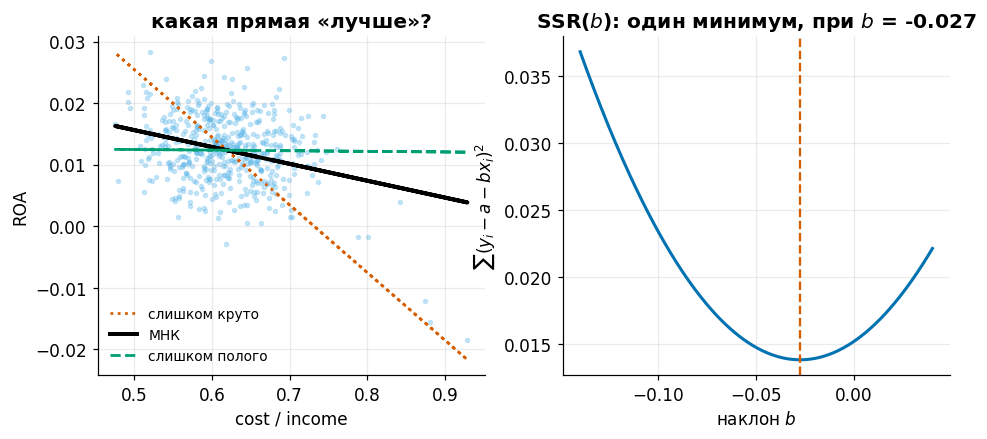

In [3]:
sub = model_df.sample(500, random_state=SEED)
xc = (sub.m_cost_income - sub.m_cost_income.mean()).to_numpy()
yc = (sub.e_roa - sub.e_roa.mean()).to_numpy()
slopes = np.linspace(-0.14, 0.04, 300)
ssr = ((yc[:, None] - slopes * xc[:, None]) ** 2).sum(axis=0)
b_hat = slopes[ssr.argmin()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(sub.m_cost_income, sub.e_roa, s=7, alpha=0.30, color="#56B4E9")
for b, ls, lw, col, lab in [(-0.11, ":", 1.8, "#D55E00", "слишком круто"),
                            (b_hat, "-", 2.6, "#000000", "МНК"),
                            (-0.001, "--", 1.8, "#009E73", "слишком полого")]:
    a = sub.e_roa.mean() - b * sub.m_cost_income.mean()
    ax1.plot(sub.m_cost_income, a + b * sub.m_cost_income,
             ls=ls, lw=lw, color=col, label=lab)
ax1.set(xlabel="cost / income", ylabel="ROA", title="какая прямая «лучше»?")
ax1.legend(loc="lower left", fontsize=9)
ax2.plot(slopes, ssr, color="#0072B2", lw=2)
ax2.axvline(b_hat, color="#D55E00", lw=1.5, ls="--")
ax2.set(xlabel="наклон $b$", ylabel="$\\sum (y_i - a - b x_i)^2$",
        title=f"SSR($b$): один минимум, при $b$ = {b_hat:.3f}")
plt.show()

### 2.2 Прямая как приближение условного среднего

Проверим утверждение буквально. Разобьём банки на 25 равнонаполненных групп по
доле NPL, посчитаем **средний ROA внутри каждой группы** — это и есть оценка
$\mathbb{E}[Y\mid X]$ без всякой функциональной формы («биннированная
диаграмма», рабочая лошадка прикладной эконометрики). Поверх — линия МНК.

Смотрим, совпадают ли оранжевые точки с чёрной линией.

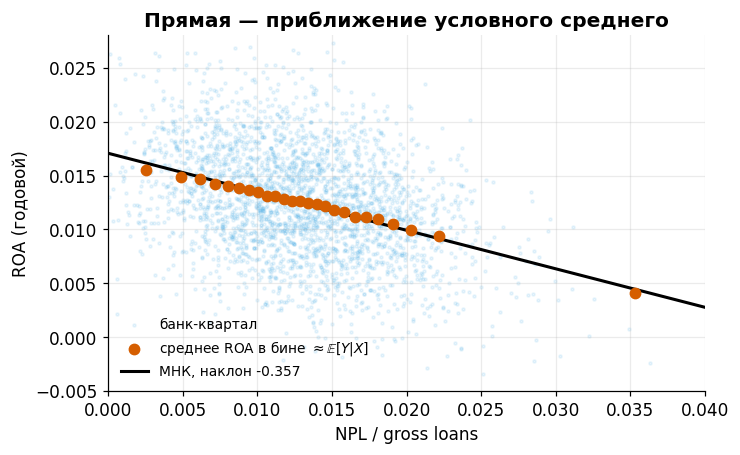

In [4]:
import statsmodels.formula.api as smf

def binned_means(x, y, bins=25, equal_width=False):
    # Среднее y внутри групп по x — оценка E[Y|X] без всякой модели.
    d = pd.DataFrame({"x": np.asarray(x, float), "y": np.asarray(y, float)}).dropna()
    cut = pd.cut if equal_width else pd.qcut        # равная ширина / равное наполнение
    d["bin"] = cut(d["x"], bins, labels=False, duplicates="drop")
    return d.groupby("bin").agg(x=("x", "mean"), y=("y", "mean"), n=("y", "size"))

bs = binned_means(model_df.a_npl_gross_loans, model_df.e_roa, bins=25)
simple = smf.ols("e_roa ~ a_npl_gross_loans", data=model_df).fit()
grid = np.linspace(0, 0.05, 50)

fig, ax = plt.subplots()
cloud = model_df.sample(3000, random_state=SEED)
ax.scatter(cloud.a_npl_gross_loans, cloud.e_roa, s=4, alpha=0.12,
           color="#56B4E9", label="банк-квартал")
ax.scatter(bs.x, bs.y, s=45, color="#D55E00", zorder=3,
           label="среднее ROA в бине $\\approx \\mathbb{E}[Y|X]$")
ax.plot(grid, simple.params["Intercept"] + simple.params["a_npl_gross_loans"] * grid,
        color="#000000", lw=2,
        label=f"МНК, наклон {simple.params['a_npl_gross_loans']:.3f}")
ax.set(xlim=(0, 0.04), ylim=(-0.005, 0.028), xlabel="NPL / gross loans",
       ylabel="ROA (годовой)", title="Прямая — приближение условного среднего")
ax.legend(loc="lower left", fontsize=9)
plt.show()

Оранжевые точки ложатся на чёрную линию — на этом диапазоне приближение
работает, и работает хорошо. Заметьте, чего эта картинка **не** показывает:
квантильные бины равнонаполнены, поэтому 98 % данных занимают левую треть
оси, а весь хвост проблемных банков схлопнут в одну точку справа. Прямая
хорошо описывает типичный банк. Про нетипичный она отсюда не сказала ничего —
и в §6.2 мы посмотрим на него отдельно.

### 2.3 Что значит «при прочих равных»

Множественная регрессия — не «много парных сразу». Коэффициент при NPL в
множественной регрессии — это наклон по NPL **после того, как из NPL и из ROA
вычтено всё, что объясняют остальные регрессоры**. Это теорема
Фриша–Во–Ловелла, и её стоит увидеть в числах, а не запомнить.

Считаем три числа: парный наклон, коэффициент из множественной регрессии, и
регрессию «остатки на остатки».

In [5]:
KEY = "a_npl_gross_loans"
others = [f for f in FEATURES if f != KEY]
b_simple = smf.ols(f"e_roa ~ {KEY}", data=model_df).fit().params[KEY]
b_multi = smf.ols(formula, data=model_df).fit().params[KEY]
rx = smf.ols(f"{KEY} ~ " + " + ".join(others), data=model_df).fit().resid
ry = smf.ols("e_roa ~ " + " + ".join(others), data=model_df).fit().resid
b_fwl = smf.ols("ry ~ rx", data=pd.DataFrame({"ry": ry, "rx": rx})).fit().params["rx"]
print(f"парная регрессия ROA на NPL   : {b_simple:+.4f}")
print(f"в множественной регрессии     : {b_multi:+.4f}")
print(f"FWL, остатки на остатки       : {b_fwl:+.4f}   <- ровно то же число")

парная регрессия ROA на NPL   : -0.3572
в множественной регрессии     : -0.2312
FWL, остатки на остатки       : -0.2312   <- ровно то же число


Парный наклон круче множественного: часть «эффекта NPL» на самом деле —
эффект капитала и издержек, которые с NPL коррелируют. Множественная
регрессия эту часть отдаёт им. **Это и есть контроль**: не магия, а вычитание
проекции.

Отсюда сразу два следствия, к которым мы вернёмся:
чем сильнее регрессоры коррелированы, тем меньше «своей» вариации остаётся у
каждого (§3.2), и тем менее устойчив его коэффициент.

## 3 · Предпосылки — What has to be true, and for which claim

Список предпосылок Гаусса–Маркова обычно заучивают целиком. Полезнее знать,
**какая предпосылка защищает какое утверждение** — потому что нарушения бывают
безобидными для одной цели и фатальными для другой.

| Ярус | Предпосылка | Что рухнет, если нарушена | Чинится |
|---|---|---|---|
| **A. Чтобы модель вообще была определена** | линейность **по параметрам**; нет полной коллинеарности | оценка не существует / не единственна | переспецификация (§6), выбросить дубль |
| **B. Чтобы $\hat\beta$ было несмещённым** | $\mathbb{E}[\varepsilon \mid X]=0$ (экзогенность) | **интерпретация коэффициента**: он больше не «эффект» | инструменты, фикс-эффекты, дизайн (S8) |
| **C. Чтобы стандартные ошибки были верны** | гомоскедастичность, независимость наблюдений | $t$-статистики, $p$-значения, дов. интервалы | робастные / кластерные SE |
| **D. Чтобы $t$ и $F$ были точны в малой выборке** | нормальность ошибок | точность $p$ при малом $n$ | ЦПТ при большом $n$; бутстрап |

Три вещи, которые стоит унести из этой таблицы:

1. **Линейность по параметрам, а не по переменным.** $y = \beta_0 + \beta_1 x + \beta_2 x^2$ —
   это линейная регрессия. Весь §6 живёт внутри этой предпосылки, а не вопреки ей.
2. **Ярус B невозможно проверить по данным.** Никакой тест не скажет, что вы
   ничего не пропустили. Это вопрос дизайна, а не диагностики — и именно поэтому
   S8 отдельная сессия.
3. **Для *прогноза* не нужен ни один ярус, кроме A.** Смещённый коэффициент с
   неверной SE может давать отличный $\hat y$. Это неочевидно и важно: §5 живёт
   по другим правилам, чем §4.

### 3.1 Диагностика: что видно на остатках

Ярусы A, C и D читаются по остаткам — ярус B, напомню, не читается ниоткуда.
Считаем четыре проверки за раз и **сначала смотрим на числа**, потом на
картинку: половина ошибок в диагностике делается ровно потому, что смотрят
только на картинку.

In [6]:
from scipy.stats import norm, skew, kurtosis
from statsmodels.stats.diagnostic import het_breuschpagan

ols_iid = smf.ols(formula, data=model_df).fit()      # classical (iid) SEs for now
resid, fitted = ols_iid.resid.to_numpy(), ols_iid.fittedvalues.to_numpy()

diag = pd.DataFrame({"f": fitted, "r": resid, "cert": model_df.cert.to_numpy()})
by_bin = (diag.assign(bin=pd.qcut(diag.f, 30, labels=False))
          .groupby("bin").agg(f=("f", "mean"), mean_r=("r", "mean"), sd_r=("r", "std")))
lags = range(1, 9)
acf_within = [diag["r"].corr(diag.groupby("cert")["r"].shift(k)) for k in lags]
z = np.sort((resid - resid.mean()) / resid.std())
q_theory = norm.ppf((np.arange(1, len(z) + 1) - 0.5) / len(z))

print(f"A  средний остаток по бинам: от {by_bin.mean_r.min()*1e4:+.1f} "
      f"до {by_bin.mean_r.max()*1e4:+.1f} б.п.")
print(f"C  sd остатка по бинам: {by_bin.sd_r.min():.5f} .. {by_bin.sd_r.max():.5f} "
      f"(разброс {(by_bin.sd_r.max()/by_bin.sd_r.min() - 1):.1%}) | "
      f"Breusch-Pagan p = {het_breuschpagan(resid, ols_iid.model.exog)[1]:.1e}")
print(f"D  скошенность {skew(resid):+.3f} | эксцесс {kurtosis(resid, fisher=False):.3f}")
print("C  автокорреляция внутри банка, лаги 1-8:", np.round(acf_within, 3))

A  средний остаток по бинам: от -3.3 до +4.1 б.п.
C  sd остатка по бинам: 0.00445 .. 0.00470 (разброс 5.5%) | Breusch-Pagan p = 1.5e-05
D  скошенность -0.020 | эксцесс 3.005
C  автокорреляция внутри банка, лаги 1-8: [0.458 0.462 0.457 0.462 0.457 0.459 0.452 0.459]


Четыре панели. Читаем каждую как ответ на вопрос «какой ярус под угрозой?».

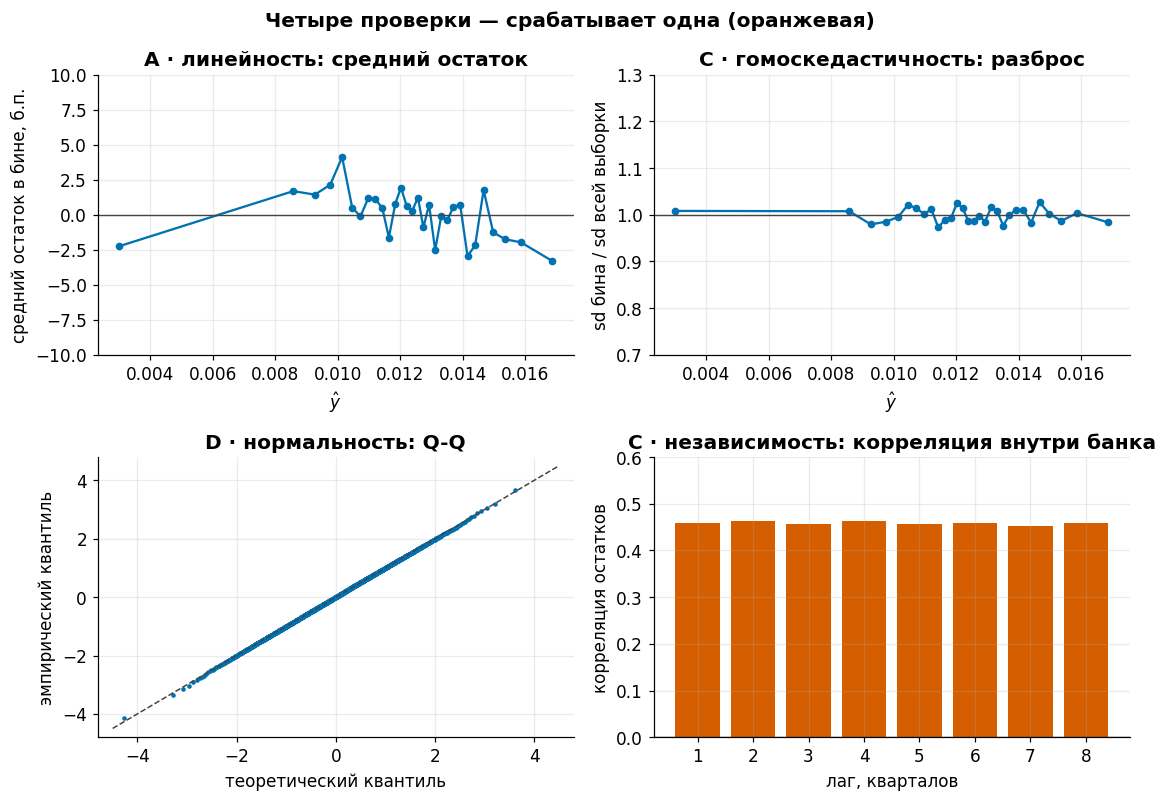

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10.5, 7.4))
ax[0, 0].plot(by_bin.f, by_bin.mean_r * 1e4, "o-", color="#0072B2", ms=4)
ax[0, 0].axhline(0, color="#444444", lw=0.9)
ax[0, 0].set(title="A · линейность: средний остаток", xlabel="$\\hat y$",
             ylabel="средний остаток в бине, б.п.", ylim=(-10, 10))
ax[0, 1].plot(by_bin.f, by_bin.sd_r / resid.std(), "o-", color="#0072B2", ms=4)
ax[0, 1].axhline(1, color="#444444", lw=0.9)
ax[0, 1].set(title="C · гомоскедастичность: разброс", xlabel="$\\hat y$",
             ylabel="sd бина / sd всей выборки", ylim=(0.7, 1.3))
ax[1, 0].plot(q_theory[::25], z[::25], ".", color="#0072B2", ms=4)
ax[1, 0].plot([-4.5, 4.5], [-4.5, 4.5], color="#444444", lw=1.0, ls="--")
ax[1, 0].set(title="D · нормальность: Q-Q", xlabel="теоретический квантиль",
             ylabel="эмпирический квантиль", xlim=(-4.8, 4.8), ylim=(-4.8, 4.8))
ax[1, 1].bar(list(lags), acf_within, color="#D55E00")
ax[1, 1].axhline(0, color="#444444", lw=0.9)
ax[1, 1].set(title="C · независимость: корреляция внутри банка",
             xlabel="лаг, кварталов", ylabel="корреляция остатков", ylim=(0, 0.6))
fig.suptitle("Четыре проверки — срабатывает одна (оранжевая)", weight="bold")
fig.tight_layout()
plt.show()

Читаем панель за панелью:

* **A (линейность) — проходит.** Средний остаток гуляет в пределах ±4 б.п.
  вокруг нуля без всякой системы. Если бы модели не хватало кривизны, здесь
  была бы дуга: систематический промах в одну сторону на краях и в другую в
  середине. Дуги нет.
* **C (гомоскедастичность) — формально не проходит, содержательно проходит.**
  Тест Бройша–Пагана даёт $p \approx 10^{-5}$ — казалось бы, приговор. Теперь
  посмотрите на величину: размах sd остатка по тридцати бинам — 5.5 %, а
  одна только выборочная погрешность оценки sd в бине из 1 700 строк даёт
  около 1.7 % на бин, то есть ожидаемый размах ровно того же порядка.
  Отклонение неотличимо от шума. При $n = 50\,000$ тест ловит что угодно;
  поймал он и это. **Значимо ≠ важно** — та же мысль, что в §4.1, только
  теперь про диагностику. Робастные SE тут почти ничего не изменят, но
  ставить их всё равно стоит: они бесплатны.
* **D (нормальность) — проходит, и это подозрительно.** Точки лежат на
  диагонали до четвёртого сигма, эксцесс 3.00, скошенность −0.02. Реальные
  банковские данные так себя **не ведут**: там жирные хвосты и левая
  скошенность. Здесь остатки идеальны, потому что генератор синтетической
  панели подмешивает гауссовский шум. Полезное напоминание, что диагностика
  проверяет и данные тоже.
* **C (независимость) — проваливается, и сильно.** Корреляция остатков внутри
  банка $\approx 0.46$ и **не затухает** с лагом: на восьмом квартале ровно та
  же, что на первом. AR(1) затухал бы геометрически; здесь плоско, а значит это
  не динамика, а **постоянный банковский эффект**. Лечится не Newey–West, а
  кластеризацией по банку (§3.3).

Итог: из четырёх проверок содержательно провалена одна. Это нормальный
результат диагностики — она не должна находить проблемы везде, она должна
показывать, **какую именно** поправку вносить.

### 3.2 Коллинеарность: почему `c_tier1_leverage` ломает капитал

`c_equity_assets` и `c_tier1_leverage` — почти одно и то же (Tier-1 капитал
к активам против собственного капитала к активам). По FWL «своей» вариации у
каждого почти не остаётся. Смотрим, что делает с ними МНК — и что происходит,
когда близнеца убрать.

In [8]:
both = smf.ols(formula, data=model_df).fit(
    cov_type="cluster", cov_kwds={"groups": model_df["cert"]})
dropped = smf.ols("e_roa ~ " + " + ".join([f for f in FEATURES
                                           if f != "c_tier1_leverage"]),
                  data=model_df).fit(cov_type="cluster",
                                     cov_kwds={"groups": model_df["cert"]})
comp = pd.DataFrame({
    "coef_both": both.params, "se_both": both.bse,
    "coef_dropped": dropped.params, "se_dropped": dropped.bse,
}).loc[["c_equity_assets", "c_tier1_leverage", "a_npl_gross_loans"]]
print("corr(equity/assets, tier1/assets) =",
      round(model_df.c_equity_assets.corr(model_df.c_tier1_leverage), 3))
print(f"R^2:  обе = {both.rsquared:.4f}   без tier1 = {dropped.rsquared:.4f}")
comp.round(4)

corr(equity/assets, tier1/assets) = 0.898
R^2:  обе = 0.3069   без tier1 = 0.3069


,coef_both,se_both,coef_dropped,se_dropped
c_equity_assets,0.1315,0.028,0.1262,0.0029
c_tier1_leverage,-0.0058,0.0302,NaN,NaN
a_npl_gross_loans,-0.2312,0.0046,-0.2312,0.0046


Корреляция 0.90. С обоими регрессорами капитал получает большой коэффициент с
огромной SE, а Tier-1 — коэффициент **неправильного знака** и незначимый: МНК
не может распределить общий эффект между близнецами и мечется. Уберите
близнеца — коэффициент почти не меняется, а SE падает примерно в десять раз.

И ключевое: **$R^2$ идентичен до четвёртого знака**. Коллинеарность не портит
прогноз — она разрушает *интерпретацию*.

#### Почему именно доверительный интервал

Механизм видно из формулы дисперсии оценки (ISLP 3.3.3):

$$
\operatorname{Var}(\hat\beta_j)
= \frac{\sigma^2}{(n-1)\,\operatorname{Var}(x_j)}
\cdot \underbrace{\frac{1}{1 - R^2_{j}}}_{\text{VIF}_j},
\qquad
R^2_{j} = R^2 \text{ регрессии } x_j \text{ на все остальные } x.
$$

Первый множитель — обычная «цена шума». Второй, **фактор инфляции дисперсии**,
и есть коллинеарность. Если $x_j$ на 83 % объясняется остальными регрессорами,
то $\text{VIF} = 1/(1-0.83) \approx 5.9$, дисперсия в 5.9 раза больше, а
**доверительный интервал шире в $\sqrt{5.9} = 2.4$ раза**.

Обратите внимание, что происходит с самим утверждением. Точечная оценка не
смещена — она правильная. Но интервал растягивается настолько, что вы больше
не можете отличить «эффект +0.08» от «эффект +0.19», хотя данных 50 тысяч
строк. Вы не потеряли информацию о *сумме* эффектов близнецов; вы потеряли
возможность разделить её между ними. Считаем VIF и ширину интервалов.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xv = np.column_stack([np.ones(len(model_df)), model_df[FEATURES].to_numpy()])
vif = pd.DataFrame({"VIF": [variance_inflation_factor(Xv, i + 1)
                            for i in range(len(FEATURES))]}, index=FEATURES)
vif["R2_j"] = 1 - 1 / vif["VIF"]                    # доля x_j, объяснённая прочими
vif["во сколько раз шире ДИ"] = np.sqrt(vif["VIF"])
ci = both.conf_int().loc[FEATURES]
vif["ширина 95% ДИ"] = (ci[1] - ci[0])
vif.sort_values("VIF", ascending=False).round(3)

,VIF,R2_j,во сколько раз шире ДИ,ширина 95% ДИ
c_equity_assets,5.892,0.83,2.427,0.11
c_tier1_leverage,5.178,0.807,2.276,0.119
a_npl_gross_loans,1.808,0.447,1.345,0.018
m_cost_income,1.274,0.215,1.129,0.002
a_llr_npl_coverage,1.121,0.108,1.059,0.001
l_loans_deposits,1,0,1,0.001
s_securities_assets,1,0,1,0.002


Два капитальных ратио несут VIF около 5–6 и расплачиваются интервалом в 2.4
раза шире; у остальных VIF близок к единице. Порог для тревоги обычно называют
$\text{VIF} > 5$ или $> 10$ — но это соглашение, а не закон: важно не число, а
то, стало ли интервал слишком широким **для вашего вопроса**.

Есть и геометрическое прочтение, самое наглядное. МНК ищет минимум суммы
квадратов в пространстве коэффициентов. Когда регрессоры ортогональны, линии
уровня RSS — окружности: сдвиг по $\beta_1$ нельзя компенсировать сдвигом по
$\beta_2$. Когда регрессоры коррелированы, окружности вытягиваются в **длинную
узкую долину**: почти любое увеличение $\beta_1$ можно почти полностью
скомпенсировать уменьшением $\beta_2$, и RSS едва изменится. Дно долины плоское,
минимум плохо определён — а ширина доверительного интервала есть не что иное,
как ширина этой долины, спроецированная на ось.

Стандартизуем обе пары регрессоров (иначе форма долины будет отражать единицы
измерения, а не корреляцию) и нарисуем линии уровня RSS.

In [10]:
zs = lambda col: ((col - col.mean()) / col.std()).to_numpy()
yz = zs(model_df.e_roa)
PAIRS = [("коллинеарные (r = 0.90)", "c_equity_assets", "c_tier1_leverage"),
         ("почти ортогональные (r = -0.01)", "a_npl_gross_loans", "s_securities_assets")]
step = np.linspace(-0.06, 0.06, 200)
panels = []
for name, v1, v2 in PAIRS:
    x1, x2 = zs(model_df[v1]), zs(model_df[v2])
    m2 = smf.ols("y ~ a + b", pd.DataFrame({"y": yz, "a": x1, "b": x2})).fit()
    b1, b2 = m2.params["a"], m2.params["b"]
    G1, G2 = np.meshgrid(b1 + step, b2 + step)
    # RSS(b1,b2) — квадратичная форма, считается из достаточных статистик
    rss = (yz @ yz - 2 * G1 * (yz @ x1) - 2 * G2 * (yz @ x2)
           + G1 ** 2 * (x1 @ x1) + 2 * G1 * G2 * (x1 @ x2) + G2 ** 2 * (x2 @ x2))
    lo, hi = m2.conf_int().loc["a"]
    panels.append((name, v1, v2, G1, G2, rss, b1, b2, lo, hi))
    print(f"{name:32s} ширина 95% ДИ для beta_1 = {hi - lo:.4f}")

коллинеарные (r = 0.90)          ширина 95% ДИ для beta_1 = 0.0354
почти ортогональные (r = -0.01)  ширина 95% ДИ для beta_1 = 0.0150


Слева — коллинеарная пара, справа — ортогональная. Оранжевая полоса на каждой
панели — маргинальный 95 %-й доверительный интервал для $\beta_1$, то есть
тень эллипса на горизонтальную ось.

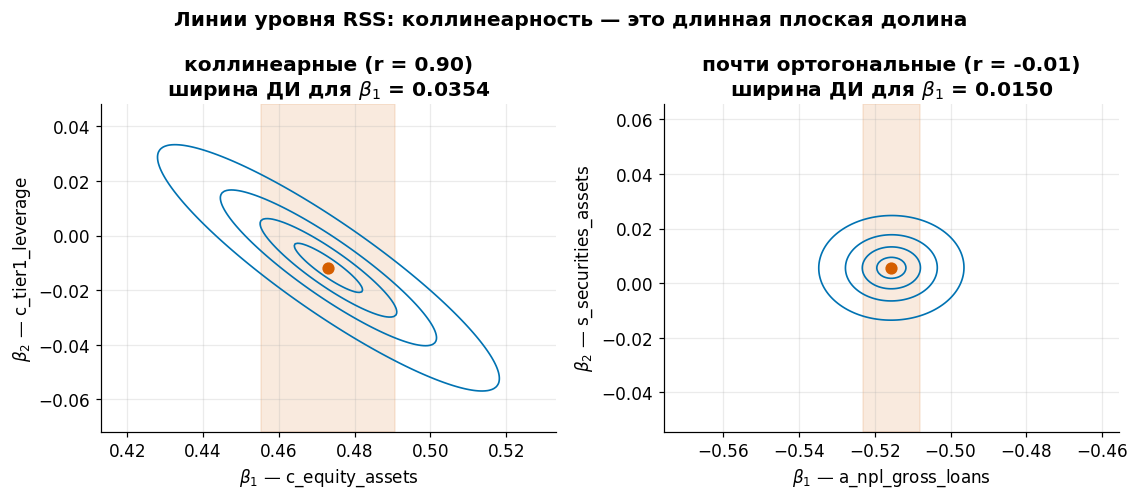

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
for ax, (name, v1, v2, G1, G2, rss, b1, b2, lo, hi) in zip(axes, panels):
    ax.contour(G1, G2, rss / rss.min(), levels=[1.00002, 1.00008, 1.0002, 1.0005],
               colors="#0072B2", linewidths=1.1)
    ax.axvspan(lo, hi, color="#D55E00", alpha=0.13)
    ax.plot(b1, b2, "o", color="#D55E00", ms=7)
    ax.set(xlabel=f"$\\beta_1$ — {v1}", ylabel=f"$\\beta_2$ — {v2}",
           xlim=(b1 - 0.06, b1 + 0.06), ylim=(b2 - 0.06, b2 + 0.06),
           title=f"{name}\nширина ДИ для $\\beta_1$ = {hi - lo:.4f}")
fig.suptitle("Линии уровня RSS: коллинеарность — это длинная плоская долина",
             weight="bold")
fig.tight_layout()
plt.show()

Слева видно всё сразу: эллипсы вытянуты по диагонали (рост капитала можно
компенсировать падением Tier-1, RSS почти не заметит), дно длинное и плоское,
и тень на ось $\beta_1$ — интервал шириной 0.035. Справа эллипсы почти круглые,
компенсировать нечем, интервал 0.015 — **в 2.4 раза уже**, ровно $\sqrt{\text{VIF}}$.

Что с этим делать — по убыванию предпочтительности:

1. **Выбросить дубликат.** Если два ратио измеряют одно и то же, вопрос
   «который из них важнее» бессмыслен по построению. Это наш случай.
2. **Сложить их в один индекс** (среднее, первая главная компонента — S6).
   Вы отказываетесь от разделения эффекта, но говорите об этом вслух.
3. **Смириться и отчитаться о совместном тесте.** $F$-тест на «оба
   коэффициента равны нулю» остаётся мощным, даже когда каждый $t$ по
   отдельности бессилен. Это часто и есть честный ответ.
4. **Сжать коэффициенты — гребневая регрессия (S3).** Она сознательно вносит
   смещение, чтобы вытащить оценку из плоской долины. Ровно тот обмен смещения
   на дисперсию, который мы разложим в §5.2.

Ярус B при этом цел: оценка не смещена. Страдает только точность.

### 3.3 Кластеризация стандартных ошибок

Панель из 50 000 банк-кварталов — это не 50 000 независимых наблюдений. У
одного банка соседние кварталы почти одинаковы: тот же менеджмент, тот же
портфель (мы это только что видели — корреляция 0.46, не затухающая).
Эффективное число наблюдений ближе к числу *банков*, чем к числу строк.

Сравним обычные и кластерные SE. Отношение — мера того, насколько
независимость внутри банка была иллюзией.

In [12]:
se = pd.DataFrame({"coef": both.params, "se_iid": ols_iid.bse, "se_cluster": both.bse})
se["inflation"] = se["se_cluster"] / se["se_iid"]
se["t_iid"] = se["coef"] / se["se_iid"]
se["t_cluster"] = se["coef"] / se["se_cluster"]
se.drop(index="Intercept").round(3)

,coef,se_iid,se_cluster,inflation,t_iid,t_cluster
c_equity_assets,0.131,0.006,0.028,5.075,23.84,4.697
c_tier1_leverage,-0.006,0.005,0.03,5.992,-1.144,-0.191
a_npl_gross_loans,-0.231,0.003,0.005,1.323,-66.64,-50.38
a_llr_npl_coverage,0.002,0,0,1.006,12.36,12.28
m_cost_income,-0.008,0,0,1.011,-20.77,-20.55
l_loans_deposits,0,0,0,0.941,0.017,0.018
s_securities_assets,0.001,0.001,0.001,1.011,1.692,1.673


Для капитальных ратио SE вырастают в **5–6 раз**, то есть $t$-статистики
падают в 5–6 раз. Регрессор, «значимый на 1 %» при наивном расчёте,
оказывается неотличимым от нуля. Для NPL инфляция около 1.3 — эта переменная
внутри банка двигается сильнее, поэтому и информации в ней больше.

Ни один коэффициент при этом не изменился: кластеризация трогает только ярус C.

### 3.4 Меню поправок — и почему выбирать надо по диагнозу

Поправок несколько, и все они делают одно и то же: пересчитывают
$\operatorname{Var}(\hat\beta)$, не трогая сам $\hat\beta$. Отличаются они тем,
**какое именно нарушение** признают.

| Поправка | Против чего | Формула ковариации | Когда брать |
|---|---|---|---|
| `nonrobust` | ничего | $\sigma^2 (X^\top X)^{-1}$ | ошибки iid — почти никогда |
| **HC1 / HC3** (White) | гетероскедастичность | $(X^\top X)^{-1} X^\top \hat\Omega X (X^\top X)^{-1}$, $\hat\Omega$ диагональная | кросс-секция, разброс зависит от $X$ |
| **HAC** (Newey–West) | автокорреляция во времени | $\hat\Omega$ с затухающими весами по лагам | один ряд, зависимость затухает |
| **Cluster** | произвольная зависимость **внутри группы** | $\hat\Omega$ блочно-диагональная по группам | панель; групп много (≥ 40) |
| GLS / WLS | то же, но эффективнее | перевзвешивание наблюдений | известна форма $\Omega$ — редко |

HC3 — версия White с поправкой на малые выборки; при $n$ в десятки тысяч
разницы с HC1 нет. GLS даёт более *эффективную* оценку, но требует знать
структуру ошибок; ошибётесь в ней — станет хуже, чем было. Поэтому прикладной
стандарт — оставить МНК и починить только SE.

Прогоним одну и ту же регрессию под всеми ковариациями и посмотрим, какая
поправка что ловит.

In [13]:
covs = {
    "nonrobust": dict(),
    "HC1 (White)": dict(cov_type="HC1"),
    "HC3": dict(cov_type="HC3"),
    "HAC (Newey-West, 8)": dict(cov_type="HAC", cov_kwds={"maxlags": 8}),
    "cluster by bank": dict(cov_type="cluster", cov_kwds={"groups": model_df["cert"]}),
}
se_menu = pd.DataFrame({name: smf.ols(formula, data=model_df).fit(**kw).bse
                        for name, kw in covs.items()})
shown = ["c_equity_assets", "a_npl_gross_loans", "m_cost_income"]
ratio = se_menu.div(se_menu["nonrobust"], axis=0).loc[shown]
ratio.columns = [c + " / naive" for c in ratio.columns]
ratio.round(2)

,nonrobust / naive,HC1 (White) / naive,HC3 / naive,"HAC (Newey-West, 8) / naive",cluster by bank / naive
c_equity_assets,1,0.99,0.99,1.78,5.08
a_npl_gross_loans,1,1.01,1.01,1.23,1.32
m_cost_income,1,1,1,0.99,1.01


Таблица читается как диагноз, а не как список опций:

* **HC1 и HC3 не меняют ничего** (отношение 0.99–1.01). Это не значит, что
  робастные SE бесполезны — это значит, что в *этих* данных
  гетероскедастичности нет, ровно как показала панель C в §3.1. Поправка
  сработала бы, если бы было что править.
* **HAC даёт ×1.78** для капитала: частично ловит зависимость, но не всю.
  Newey–West рассчитан на затухающую автокорреляцию, а у нас (§3.1) она
  **плоская** — постоянный банковский эффект. Восьми лагов не хватает, и
  сколько ни добавляй, конструкция не та.
* **Кластеризация даёт ×5.08.** Она не предполагает никакой формы зависимости
  внутри банка — допускает любую. Именно поэтому она здесь и работает.

Посмотрим на то же самое в единицах, которые читает человек: ширина
доверительного интервала для коэффициента при капитале.

In [14]:
widths = []
for name, kw in covs.items():
    ci = smf.ols(formula, data=model_df).fit(**kw).conf_int().loc["c_equity_assets"]
    widths.append({"поправка": name, "нижняя": ci[0], "верхняя": ci[1],
                   "ширина ДИ": ci[1] - ci[0]})
w = pd.DataFrame(widths).set_index("поправка")
w["во сколько раз шире наивного"] = w["ширина ДИ"] / w["ширина ДИ"].iloc[0]
w.round(4)

,нижняя,верхняя,ширина ДИ,во сколько раз шире наивного
поправка,,,,
nonrobust,0.1207,0.1423,0.0216,1
HC1 (White),0.1208,0.1422,0.0214,0.9901
HC3,0.1208,0.1422,0.0214,0.9902
"HAC (Newey-West, 8)",0.1122,0.1508,0.0386,1.784
cluster by bank,0.0766,0.1864,0.1097,5.075


Наивный интервал: $[0.121,\ 0.142]$ — узкий и уверенный. Кластерный:
$[0.077,\ 0.186]$ — **в пять раз шире**. Содержательно это разные утверждения:
первое говорит «эффект капитала на ROA известен с точностью до 2 б.п. на
процентный пункт», второе — «где-то между 8 и 19 б.п.». Второе честное.

> **Правило выбора.** Сначала диагноз, потом поправка. Гетероскедастичность
> лечится White, затухающая автокорреляция — Newey–West, произвольная
> зависимость внутри сущности — кластером. Ставить кластер «на всякий случай»
> дёшево и почти всегда правильно на панели; ставить его при 5 кластерах —
> ошибка (асимптотика по числу *групп*, не наблюдений: нужно хотя бы 40).

> **По какой единице кластеризовать.** По той, на уровне которой происходит
> процесс. Здесь — банк. В S8 при DiD это будет штат: регулирование меняется
> по штатам, а не по банкам, и кластер по банку там занизит SE так же, как
> здесь его занижал `nonrobust`.

> **Чего поправки не делают.** Ни одна из них не чинит смещение. Если
> нарушена экзогенность (ярус B), робастные SE дадут вам честный интервал
> вокруг неправильного числа.

## 4 · Как читать таблицу — Reading the regression table

Печатаем полную таблицу и разбираем её построчно. Это тот объект, который вы
покажете на защите, и каждое число в нём должны уметь объяснить.

In [15]:
print(both.summary())

                            OLS Regression Results                            
Dep. Variable:                  e_roa   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     1150.
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:32:10   Log-Likelihood:             1.9839e+05
No. Observations:               49983   AIC:                        -3.968e+05
Df Residuals:                   49975   BIC:                        -3.967e+05
Df Model:                           7                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.0039    

**Шапка — про выборку и про подгонку в целом.**

* `No. Observations` — сколько строк реально участвовало. Сравните с исходной
  панелью: 927 строк выпали по пропускам, и это надо было заметить.
* `Covariance Type: cluster` — **самая важная строка шапки**. Она говорит,
  по какому правилу посчитаны все SE справа. Если здесь `nonrobust`, а данные
  панельные, дальше можно не читать.
* `R-squared` = 0.307 — доля дисперсии ROA, объяснённая моделью **на этой же
  выборке**. Это не качество прогноза (§5).
* `Adj. R-squared` штрафует за число регрессоров. Здесь совпадает с $R^2$:
  7 регрессоров на 50 000 наблюдений — штраф исчезающий.
* `F-statistic` / `Prob (F-statistic)` — тест «все наклоны равны нулю разом».
  При $n = 50\,000$ он почти всегда отвергается и почти ничего не сообщает.
* `AIC` / `BIC` — для сравнения *вложенных* спецификаций на одних данных;
  BIC штрафует сложность жёстче.

**Тело — про отдельные коэффициенты.**

* `coef` — производная $\partial\,\mathbb{E}[y]/\partial x_j$ при прочих
  равных, **в единицах данных**. `a_npl_gross_loans = -0.2312` означает: доля
  NPL выше на 1.0 (то есть на 100 п.п.) → ROA ниже на 0.2312. Абсурдный
  масштаб; переводить обязательно (ниже).
* `std err` — насколько бы коэффициент гулял при повторной выборке. Здесь —
  кластерная версия.
* `t` = `coef` / `std err`; `P>|t|` — вероятность увидеть такое $t$, **если бы**
  истинный коэффициент был нулём. Не вероятность того, что коэффициент нулевой.
* `[0.025 0.975]` — доверительный интервал. Читайте **его**, а не звёздочки:
  интервал показывает и знак, и правдоподобный размер эффекта.

**Подвал — про остатки.** `Omnibus` и `Jarque-Bera` тестируют нормальность
остатков (ярус D), `Skew` и `Kurtosis` говорят, чем именно она нарушена.
`Durbin-Watson` = 1.09 при «автокорреляции нет» = 2 — то же самое, что мы
видели на четвёртой панели §3.1. `Cond. No.` = 683 — число обусловленности
$X$; сотни и выше сигналят о коллинеарности (§3.2).

### 4.1 Из коэффициентов — в величины, которыми говорят

`-0.2312` ничего не значит для человека, принимающего решение. Переведём: что
будет с ROA (в базисных пунктах), если ратио вырастет на **1 процентный
пункт** — тот сдвиг, который в банке реально обсуждают.

In [16]:
ci = both.conf_int().loc[FEATURES]
# коэффициент * 0.01 -> эффект от +1 п.п.; * 1e4 -> в базисных пунктах ROA
eff = pd.DataFrame({"effect_bps": both.params[FEATURES] * 0.01 * 1e4,
                    "lo_bps": ci[0] * 0.01 * 1e4,
                    "hi_bps": ci[1] * 0.01 * 1e4,
                    "p": both.pvalues[FEATURES]}).round(2)
eff["|t|"] = (both.params[FEATURES] / both.bse[FEATURES]).abs().round(1)
eff.sort_values("effect_bps")

,effect_bps,lo_bps,hi_bps,p,|t|
a_npl_gross_loans,-23.12,-24.01,-22.22,0,50.4
m_cost_income,-0.82,-0.9,-0.75,0,20.6
c_tier1_leverage,-0.58,-6.51,5.35,0.85,0.2
l_loans_deposits,0,-0.06,0.06,0.99,0
s_securities_assets,0.09,-0.01,0.19,0.09,1.7
a_llr_npl_coverage,0.25,0.21,0.29,0,12.3
c_equity_assets,13.15,7.66,18.64,0,4.7


Теперь таблицу можно произнести вслух: *«банк-квартал, где доля проблемных
кредитов на процентный пункт выше, показывает ROA примерно на 23 б.п. ниже;
доверительный интервал — от 22 до 24 б.п.»* Это высказывание, которое можно
проверить и оспорить.

Сравните теперь два ранжирования — по $|t|$ и по размеру эффекта:

* `m_cost_income`: $|t| = 20.6$, эффект **0.8 б.п.** Значимость запредельная,
  величина смехотворная — процентный пункт cost/income стоит меньше
  одного базисного пункта ROA.
* `c_equity_assets`: $|t| = 4.7$, эффект **13.2 б.п.** В четыре раза менее
  «значим» и в шестнадцать раз важнее.

**Значимость и величина — разные вопросы**, и при $n = 50\,000$ первый почти
не несёт информации: значимым становится всё. Интересно только то, что ещё и
большое — а это видно лишь после перевода в единицы, которыми пользуются люди.

### 4.2 Чего в таблице нет

Три вопроса, на которые она **не отвечает**, — и на защите спросят именно их:

1. **Причинность.** Коэффициент при NPL — не «эффект выдачи плохих кредитов на
   прибыль». Плохие кредиты и низкая прибыль могут иметь общую причину (слабый
   менеджмент, региональный шок). Ярус B непроверяем, помните?
2. **Прогноз.** $R^2 = 0.307$ получен на тех же данных, на которых модель
   подгонялась. Это верхняя граница, а не оценка. §5.
3. **Устойчивость.** Таблица посчитана на всей панели 2001–2023, включая
   кризис. Оценка на подпериодах может дать другие знаки — и это была бы
   куда более интересная находка, чем звёздочки.

## 5 · Предсказательная сила — How well does it predict?

Переключаем роль. В §4 нас интересовал $\hat\beta$; теперь он безразличен,
нужен хороший $\hat y$ для банка-квартала, **которого модель не видела**.
Критерий меняется с $t$-статистики на ошибку вне выборки.

Как делить? Супервайзер в квартале $t$ располагает данными только до $t$.
Значит, делим **по времени**: учимся на `repdte <= 2015-12-31`, проверяем на
том, что после. Одна строка кода — и это самая важная строка в ноутбуке.
Случайное перемешивание положило бы один и тот же банк в обе половины — но
это сюжет S3; пока держим принцип «дели *до* того, как подгоняешь».

Сравниваем не с нулём, а с двумя тупыми моделями: «всегда средний ROA
обучающей выборки» и «ROA прошлого квартала». Модель, которая не бьёт обе,
не заработала своего места.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error as rmse, r2_score, mean_absolute_error

fit_df = model_df.copy()
fit_df["roa_lag"] = fit_df.groupby("cert")["e_roa"].shift(1)
train = (fit_df.repdte <= "2015-12-31").to_numpy()   # учимся на прошлом
test = ~train                                        # проверяем на будущем
X, y = fit_df[FEATURES], fit_df["e_roa"]
lr = LinearRegression().fit(X[train], y[train])
p_train, p_test = lr.predict(X[train]), lr.predict(X[test])
naive_mean = np.full(test.sum(), y[train].mean())
naive_lag = fit_df.loc[test, "roa_lag"].fillna(y[train].mean())
print(f"train: {train.sum():,} строк (<=2015) | test: {test.sum():,} строк (>2015)")

train: 32,399 строк (<=2015) | test: 17,584 строк (>2015)


Четыре метрики на одной таблице. RMSE и MAE — в единицах ROA; чтобы их можно
было произнести, тут же переводим в базисные пункты.

In [18]:
def score(y_true, y_pred, name):
    return {"model": name, "RMSE": rmse(y_true, y_pred),
            "RMSE_bps": rmse(y_true, y_pred) * 1e4,
            "MAE_bps": mean_absolute_error(y_true, y_pred) * 1e4,
            "R2": r2_score(y_true, y_pred)}

report = pd.DataFrame([
    score(y[train], p_train, "OLS, на обучении (in-sample)"),
    score(y[test], p_test, "OLS, на отложенной (out-of-sample)"),
    score(y[test], naive_mean, "наивная: средний ROA обучения"),
    score(y[test], naive_lag, "наивная: ROA прошлого квартала"),
]).set_index("model")
report.round({"RMSE": 6, "RMSE_bps": 1, "MAE_bps": 1, "R2": 3})

,RMSE,RMSE_bps,MAE_bps,R2
model,,,,
"OLS, на обучении (in-sample)",0.00459,45.9,36.7,0.366
"OLS, на отложенной (out-of-sample)",0.004536,45.4,36.2,0.157
наивная: средний ROA обучения,0.004947,49.5,39.5,-0.003
наивная: ROA прошлого квартала,0.005461,54.6,43.6,-0.222


Три наблюдения, и все три — про то, как **не** надо читать такую таблицу.

1. **$R^2$ падает с 0.366 до 0.157, а RMSE при этом… улучшается** (45.9 → 45.4
   б.п.). Противоречия нет: $R^2$ — это ошибка, нормированная на дисперсию $y$
   *в окне оценки*, а после 2015 года ROA банков разбросан меньше (кризис
   позади). **Сравнивать $R^2$ между разными выборками нельзя.** RMSE
   сравнивать можно.
2. **Модель бьёт «средний ROA» на ~8 %** (45.4 против 49.5 б.п.). Не разгром.
   Семь балансовых ратио объясняют небольшую часть квартальной прибыльности —
   и это честный результат, а не повод искать спецификацию покрасивее.
3. **«ROA прошлого квартала» (54.6 б.п.) хуже, чем «просто среднее».** В этой
   панели квартальная прибыль сильно зашумлена, поэтому один прошлый квартал —
   плохой прогноз. Наивная модель не обязана быть сильной; её обязанность —
   быть *проверенной*.

Одной метрики мало: RMSE усредняет и прячет, *где* модель ошибается. Смотрим
прогноз против факта и распределение остатков на отложенной выборке.

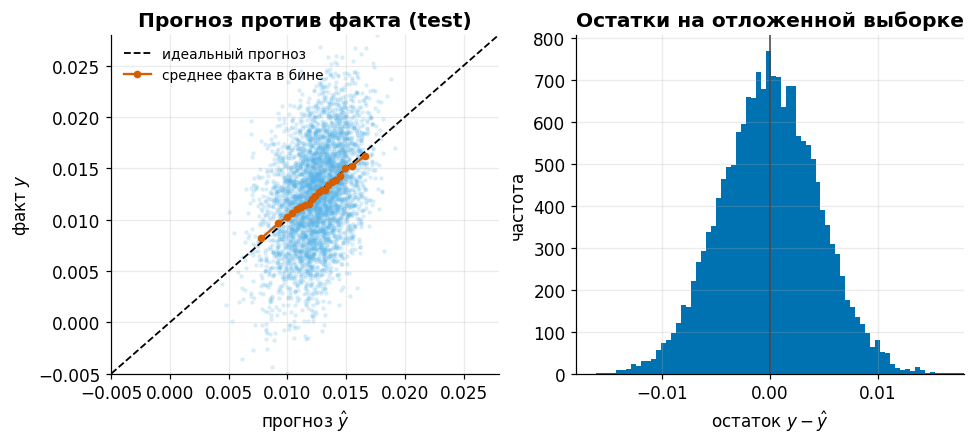

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
idx = rng.choice(np.flatnonzero(test), 4000, replace=False)
ax1.scatter(p_test[np.searchsorted(np.flatnonzero(test), idx)],
            y.to_numpy()[idx], s=4, alpha=0.15, color="#56B4E9")
lims = (-0.005, 0.028)
ax1.plot(lims, lims, color="#000000", lw=1.2, ls="--", label="идеальный прогноз")
pb = binned_means(p_test, y[test], 20)
ax1.plot(pb.x, pb.y, "o-", color="#D55E00", ms=4, label="среднее факта в бине")
ax1.set(xlim=lims, ylim=lims, xlabel="прогноз $\\hat y$", ylabel="факт $y$",
        title="Прогноз против факта (test)")
ax1.legend(loc="upper left", fontsize=9)
ax2.hist(y[test] - p_test, bins=80, color="#0072B2")
ax2.axvline(0, color="#444444", lw=1)
ax2.set(xlim=(-0.018, 0.018), xlabel="остаток $y - \\hat y$", ylabel="частота",
        title="Остатки на отложенной выборке")
plt.show()

Слева — калибровка: там, где модель обещает $x$, факт в среднем тоже около
$x$. Отклонения не превышают 4 б.п. при разбросе самой цели в 50 б.п. Одна
систематическая деталь всё же есть: на левом краю факт лежит **выше** линии —
для банков, которым модель пророчит худшую прибыльность, она в среднем
перестраховывается. Это регрессия к среднему, обычное свойство МНК: прогноз
всегда менее разбросан, чем факт.

Справа — остатки: симметричные, без длинных хвостов (скошенность ≈ 0). Но
обратите внимание на масштаб. Половина ошибок укладывается в ±36 б.п., а
1 % — превышает 105 б.п. Для банка с ROA около 1.2 % промах в один процентный
пункт означает, что модель перепутала прибыльный год с убыточным.

И главное, чего эта пара картинок **не** показывает: как модель ведёт себя на
тех тридцати банках, ради которых весь курс и затеян. Их здесь просто не
видно — они утонули в 17 тысячах здоровых. К этому вернёмся в §6.5.

### 5.1 Гибкость: почему нельзя просто «добавить членов»

Естественная идея: раз прямой мало (§3.1), добавим квадраты и попарные
произведения. Это увеличит $R^2$ на обучении **гарантированно**. Вопрос — что
станет с ошибкой на отложенной выборке.

Ответ зависит от того, **сколько наблюдений приходится на параметр**. Прогоним
одну и ту же лесенку сложности (7 регрессоров → степень 2 → степень 3) на
двух обучающих выборках: маленькой (200 строк) и полной (32 тысячи).

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

def flex_curve(rows):
    out = []
    for deg in (1, 2, 3):
        pipe = make_pipeline(StandardScaler(),
                             PolynomialFeatures(deg, include_bias=False),
                             LinearRegression())
        pipe.fit(X.loc[rows], y.loc[rows])
        out.append({"terms": pipe[-1].coef_.size,
                    "train": rmse(y.loc[rows], pipe.predict(X.loc[rows])),
                    "test": rmse(y[test], pipe.predict(X[test]))})
    return pd.DataFrame(out).set_index("terms")

small_rows = rng.choice(np.flatnonzero(train), 200, replace=False)
curve_small = flex_curve(small_rows)
curve_full = flex_curve(np.flatnonzero(train))
(curve_small * 1e4).round(1)

,train,test
terms,,
7,40.5,46.7
35,37.4,48.8
119,25.6,87.4


Слева — маленькая выборка, справа — полная. Одна и та же лесенка сложности,
противоположные выводы.

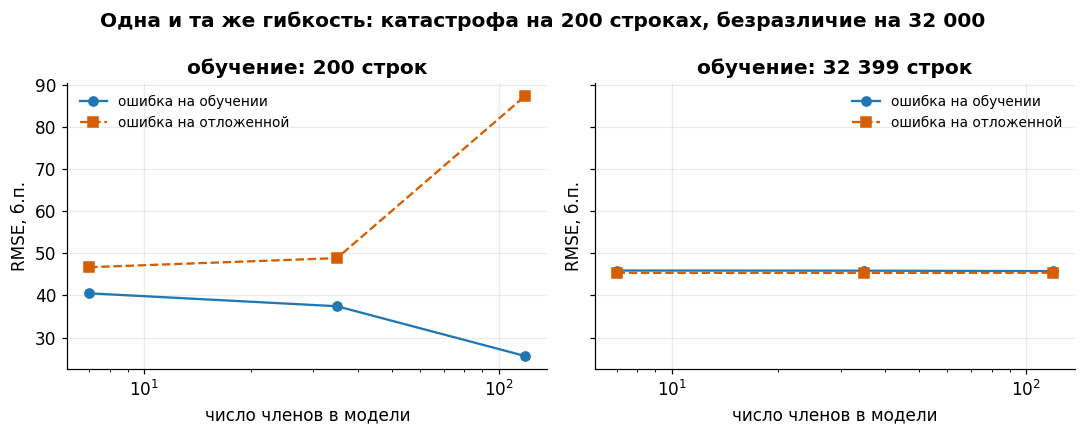

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, curve, ttl in [(axes[0], curve_small, "обучение: 200 строк"),
                       (axes[1], curve_full, "обучение: 32 399 строк")]:
    ax.plot(curve.index, curve["train"] * 1e4, "o-", label="ошибка на обучении")
    ax.plot(curve.index, curve["test"] * 1e4, "s--", color="#D55E00",
            label="ошибка на отложенной")
    ax.set(xlabel="число членов в модели", ylabel="RMSE, б.п.", title=ttl,
           xscale="log")
    ax.legend(fontsize=9)
fig.suptitle("Одна и та же гибкость: катастрофа на 200 строках, "
             "безразличие на 32 000", weight="bold")
fig.tight_layout()
plt.show()

На 200 строках переход к 119 членам роняет ошибку обучения с 40.5 до 25.6
б.п. и **увеличивает ошибку прогноза почти вдвое** — с 46.7 до 87.4 б.п. На полной выборке те же 119 членов
не делают ничего: 32 тысячи наблюдений на 119 параметров — модели просто негде
запомнить шум.

Мораль не «сложные модели плохи», а: **опасность гибкости измеряется не в
числе членов, а в числе наблюдений на член.**

### 5.2 Откуда берётся этот разворот: смещение и дисперсия

Разложим ошибку. На банковских данных этого не сделать — истинная $f$ не
наблюдаема. Поэтому симуляция: придумываем $f$ сами, много раз разыгрываем
обучающую выборку и смотрим, как ведёт себя оценка.

$$
\mathbb{E}_{D,\varepsilon}\big[(y_0 - \hat f(x_0))^2\big]
= \underbrace{\big(\mathbb{E}_D[\hat f(x_0)] - f(x_0)\big)^2}_{\text{смещение}^2}
+ \underbrace{\operatorname{Var}_D[\hat f(x_0)]}_{\text{дисперсия}}
+ \underbrace{\sigma^2}_{\text{несводимая}}
$$

**Смещение²** — систематический промах слишком жёсткой модели; эконометристу
знакомо как смещение пропущенной переменной. **Дисперсия** — чувствительность
$\hat f$ к тому, какая именно выборка досталась. **$\sigma^2$** — пол, ниже
которого не опускается никто.

In [22]:
def f_true(x):
    return np.sin(1.6 * x) + 0.5 * x           # the truth we get to see
def draw(n, noise=0.35):
    x = rng.uniform(-3, 3, n)
    return x, f_true(x) + rng.normal(0, noise, n)

NOISE, N_REPS, N_TRAIN = 0.35, 150, 40
x_grid = np.linspace(-3, 3, 60); f_grid = f_true(x_grid)
degrees = range(1, 11)
preds = {d: np.empty((N_REPS, x_grid.size)) for d in degrees}
test_mse = {d: [] for d in degrees}
for r in range(N_REPS):
    xt, yt = draw(N_TRAIN); xv, yv = draw(400)
    for d in degrees:
        coef = np.polyfit(xt, yt, d)
        preds[d][r] = np.polyval(coef, x_grid)
        test_mse[d].append(np.mean((np.polyval(coef, xv) - yv) ** 2))
decomp = pd.DataFrame({
    "bias2": [np.mean((preds[d].mean(0) - f_grid) ** 2) for d in degrees],
    "variance": [np.mean(preds[d].var(0)) for d in degrees],
    "irreducible": NOISE ** 2,
    "test_mse": [np.mean(test_mse[d]) for d in degrees]}, index=list(degrees))
decomp.round(4)

,bias2,variance,irreducible,test_mse
1,0.5021,0.0358,0.1225,0.656
2,0.5039,0.063,0.1225,0.6817
3,0.1181,0.0352,0.1225,0.2572
4,0.1246,0.0768,0.1225,0.2917
5,0.0054,0.0328,0.1225,0.1551
6,0.0069,0.0552,0.1225,0.169
7,0.0005,0.1096,0.1225,0.1986
8,0.0008,0.5017,0.1225,0.4182
9,0.0044,2.361,0.1225,1.409
10,0.0281,2.27,0.1225,1.243


Слева — что значит «смещение» и «дисперсия» глазами: серые линии это одна и та
же модель, обученная на разных выборках. Справа — то же самое числами.

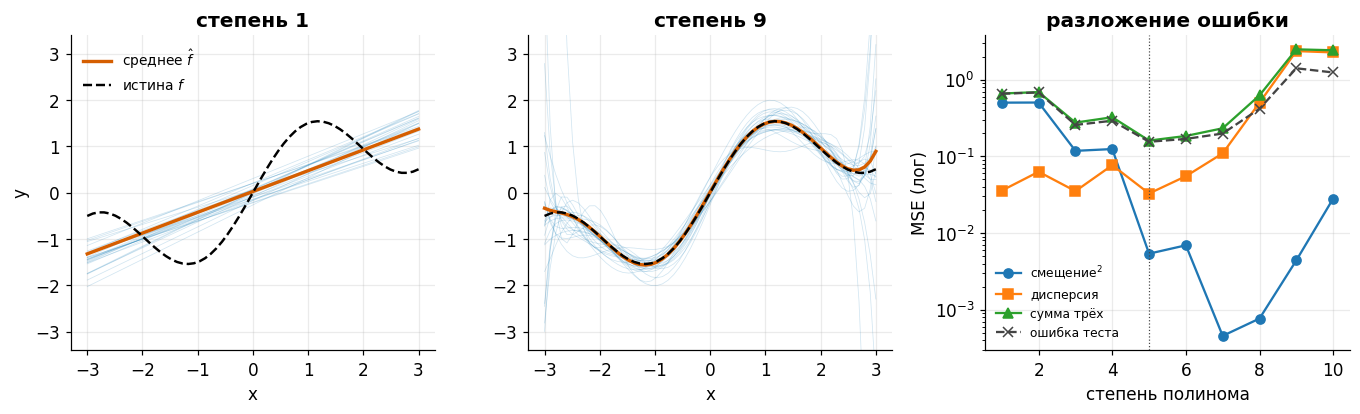

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.9))
for k, d in enumerate((1, 9)):
    for r in range(0, N_REPS, 6):
        ax[k].plot(x_grid, preds[d][r], color="#0072B2", lw=0.5, alpha=0.18)
    ax[k].plot(x_grid, preds[d].mean(0), color="#D55E00", lw=2.2, label="среднее $\\hat f$")
    ax[k].plot(x_grid, f_grid, color="#000000", lw=1.6, ls="--", label="истина $f$")
    ax[k].set(title=f"степень {d}", xlabel="x", ylim=(-3.4, 3.4))
ax[0].set_ylabel("y"); ax[0].legend(loc="upper left", fontsize=9)
ax[2].plot(decomp.index, decomp.bias2, "o-", label="смещение$^2$")
ax[2].plot(decomp.index, decomp.variance, "s-", label="дисперсия")
ax[2].plot(decomp.index, decomp.bias2 + decomp.variance + decomp.irreducible,
           "^-", label="сумма трёх")
ax[2].plot(decomp.index, decomp.test_mse, "x--", color="#444444", label="ошибка теста")
ax[2].axvline(decomp.test_mse.idxmin(), color="#444444", lw=0.8, ls=":")
ax[2].set(yscale="log", xlabel="степень полинома", ylabel="MSE (лог)",
          title="разложение ошибки"); ax[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

Слева (степень 1): подгонки лежат друг на друге — **дисперсия мала**, но все
одинаково мимо синуса — **смещение велико**. В середине (степень 9): в среднем
попадает, но каждая отдельная подгонка пляшет — смещение мало, дисперсия
велика. Справа: сумма трёх компонент совпадает с эмпирической ошибкой теста
(это тождество, а не совпадение), и минимум ошибки лежит **не там, где
смещение равно нулю**, а посередине.

Отсюда — тезис, на котором держится вся оставшаяся часть курса: *немного
смещения в обмен на много дисперсии — это выгодная сделка.* В S3 она
называется регуляризацией.

## 6 · За пределами линейности — Beyond the straight line

Напомню §3: линейность требуется **по параметрам**. $\beta_2 x^2$,
$\beta_3 \log x$, $\beta_4 x_1 x_2$ — всё это по-прежнему МНК, всё это
считается той же формулой. Три инструмента:

| Приём | Формула | Что моделирует |
|---|---|---|
| **Логарифм** | $\log y$, $\log x$ | мультипликативность, эластичности, скошенные величины |
| **Степень** | $x, x^2, x^3$ | убывающая/возрастающая отдача, точка перегиба |
| **Взаимодействие** | $x_1 \cdot x_2$ | наклон по $x_1$ **зависит** от уровня $x_2$ |

(Есть и четвёртый — сплайны и биннинг: кусочная гибкость без глобального
взрыва на краях. ISLP 7; в этом курсе они всплывут в S5 как естественный
предел деревьев.)

### 6.1 Как читать коэффициенты после лога

Самая полезная таблица семестра. $\beta$ — коэффициент при $x$:

| Спецификация | Читается как | Единица $\beta$ |
|---|---|---|
| $y = \beta x$ | $x$ вырос на 1 → $y$ вырос на $\beta$ | единицы $y$ на единицу $x$ |
| $\log y = \beta x$ | $x$ вырос на 1 → $y$ вырос на $\approx 100\beta\,\%$ | полуэластичность |
| $y = \beta \log x$ | $x$ вырос на 1 % → $y$ вырос на $\beta/100$ | единицы $y$ |
| $\log y = \beta \log x$ | $x$ вырос на 1 % → $y$ вырос на $\beta\,\%$ | **эластичность** |

Приближение $100\beta\%$ годится примерно до $|\beta| \lesssim 0.2$; точный
ответ — $100(e^{\beta} - 1)\%$.

Классический банковский вопрос в форме лог-лог: **есть ли экономия на
масштабе?** Регрессируем логарифм непроцентных расходов на логарифм активов —
коэффициент прямо читается как эластичность.

In [24]:
scale_df = panel[["noninterest_exp", "assets", "cert"]].dropna()
scale_df = scale_df[(scale_df.noninterest_exp > 0) & (scale_df.assets > 0)]
scale = smf.ols("np.log(noninterest_exp) ~ np.log(assets)", data=scale_df).fit(
    cov_type="cluster", cov_kwds={"groups": scale_df["cert"]})
b = scale.params["np.log(assets)"]
lo, hi = scale.conf_int().loc["np.log(assets)"]
print(f"эластичность расходов по активам = {b:.3f}  (95% CI {lo:.3f}..{hi:.3f})")
print(f"R^2 = {scale.rsquared:.3f}   n = {int(scale.nobs):,}")

эластичность расходов по активам = 1.000  (95% CI 0.998..1.001)
R^2 = 0.983   n = 50,910


Эластичность 1.000: активы больше на 1 % → расходы больше на 1 %. Постоянная
отдача от масштаба, экономии нет. **Осторожно: это артефакт синтетических
данных** — в генераторе расходы построены пропорционально активам, так что
единица здесь была неизбежна. На реальной панели FDIC эта оценка обычно ниже
единицы, и вот *почему* она ниже — уже содержательный вопрос. Проговариваю это
явно, потому что на защите вас спросят, откуда взялось круглое число.

### 6.2 Кривизна: одна переменная, две цели, две разные формы

Вернёмся к картинке из §2.2 и починим её главный дефект. Бины теперь равной
**ширины**, а не равного наполнения: нас интересует именно хвост, а
квантильные бины схлопывали его в одну точку. И строим условное среднее для
**двух** целей сразу — ROA и ROE.

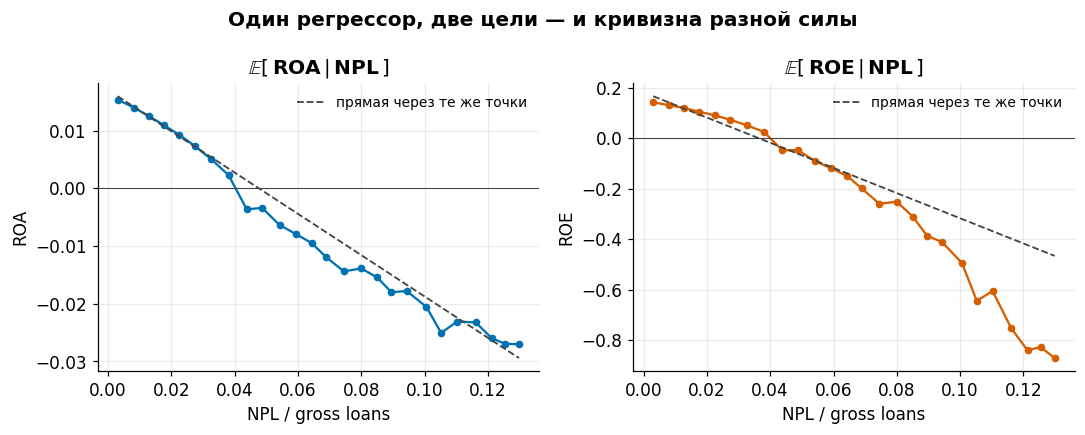

In [25]:
curv = panel[["e_roa", "e_roe", "a_npl_gross_loans", "c_equity_assets"]] \
    .replace([np.inf, -np.inf], np.nan).dropna()
roa_b = binned_means(curv.a_npl_gross_loans, curv.e_roa, 26, equal_width=True)
roe_b = binned_means(curv.a_npl_gross_loans, curv.e_roe, 26, equal_width=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, bnd, lab, col in [(ax[0], roa_b, "ROA", "#0072B2"),
                         (ax[1], roe_b, "ROE", "#D55E00")]:
    a.plot(bnd.x, bnd.y, "o-", color=col, ms=4)
    lin = np.polyfit(bnd.x, bnd.y, 1, w=np.sqrt(bnd.n))
    a.plot(bnd.x, np.polyval(lin, bnd.x), color="#444444", lw=1.2, ls="--",
           label="прямая через те же точки")
    a.axhline(0, color="#444444", lw=0.7)
    a.set(xlabel="NPL / gross loans", ylabel=lab,
          title=f"$\\mathbb{{E}}[\\,${lab}$\\,|\\,$NPL$\\,]$")
    a.legend(fontsize=9)
fig.suptitle("Один регрессор, две цели — и кривизна разной силы", weight="bold")
fig.tight_layout()
plt.show()

Обе кривые гнутся, но по-разному, и разница не косметическая.

**ROA** отходит от прямой в середине диапазона и **выполаживается** на правом
краю: у банка с 12 % плохих кредитов следующий процентный пункт отнимает
меньше, чем у банка с 5 %. Так и должно быть — потери ROA за квартал
ограничены сверху тем, что банк физически может списать.

**ROE** не выполаживается вообще. Падение **ускоряется** до самого края, и
прямая недооценивает потери примерно вдвое.

Это не случайность и не шум, и — важно — **это можно было предсказать до
всякого графика**, из тождества:

$$ \text{ROE} = \frac{\text{Прибыль}}{\text{Капитал}}
= \underbrace{\frac{\text{Прибыль}}{\text{Активы}}}_{\text{ROA}}
\times \underbrace{\frac{\text{Активы}}{\text{Капитал}}}_{\text{леверидж}} $$

Плохие кредиты бьют по ROA *и одновременно* съедают капитал, увеличивая
мультипликатор. Два эффекта перемножаются. А произведение двух эффектов — это
ровно то, что моделируется **взаимодействием**.

Тождество проверяемо. Если оно верно, то в любом диапазоне NPL отношение
локального наклона ROE к локальному наклону ROA обязано равняться
мультипликатору левериджа $A/E$ — а он тем больше, чем тоньше капитал.
Считаем наклоны в четырёх диапазонах и сравниваем с $1/(E/A)$, наблюдаемым
в тех же строках.

In [26]:
segments = [(0.00, 0.03), (0.03, 0.06), (0.06, 0.09), (0.09, 0.14)]
rows = []
for lo, hi in segments:
    seg = curv[(curv.a_npl_gross_loans >= lo) & (curv.a_npl_gross_loans < hi)]
    rows.append({"NPL": f"{lo:.0%}-{hi:.0%}", "n": len(seg),
                 "наклон ROA": np.polyfit(seg.a_npl_gross_loans, seg.e_roa, 1)[0],
                 "наклон ROE": np.polyfit(seg.a_npl_gross_loans, seg.e_roe, 1)[0],
                 "1/(E/A) здесь": 1 / seg.c_equity_assets.mean()})
slopes = pd.DataFrame(rows).set_index("NPL")
slopes["отношение наклонов"] = slopes["наклон ROE"] / slopes["наклон ROA"]
slopes[["n", "наклон ROA", "наклон ROE", "отношение наклонов", "1/(E/A) здесь"]].round(2)

,n,наклон ROA,наклон ROE,отношение наклонов,1/(E/A) здесь
NPL,,,,,
0%-3%,49823,-0.32,-2.7,8.47,9.53
3%-6%,233,-0.54,-6.6,12.12,12.24
6%-9%,148,-0.29,-7.84,27.27,18.61
9%-14%,106,-0.24,-13.49,55.91,28.85


Отношение наклонов растёт 8.5 → 12.1 → 27.3 → 55.9, а мультипликатор левериджа
в тех же строках — 9.5 → 12.2 → 18.6 → 28.9. Тот же порядок, то же
направление: **кривизна ROE — это леверидж, а не артефакт**. Отношение
обгоняет мультипликатор справа, потому что внутри самого диапазона капитал
продолжает таять, и второй эффект накладывается на первый.

Заметьте, что мы только что сделали: вывели форму из тождества, предсказали
наблюдаемое следствие и проверили его в данных — **до** того, как что-либо
оценивать. Именно этого не хватает, когда квадрат добавляют «потому что на
графике вроде гнулось».

### 6.3 Что нелинейность делает с поверхностью отклика

Прежде чем оценивать, посмотрим на геометрию. С двумя регрессорами модель —
это **поверхность** над плоскостью $(x_1, x_2)$, и каждый добавленный член
меняет её форму вполне определённым образом:

| Модель | Поверхность | Наклон по $x_1$ |
|---|---|---|
| $\beta_1 x_1 + \beta_2 x_2$ | **плоскость** | $\beta_1$ — один и тот же везде |
| $+\ \beta_{12}\,x_1 x_2$ | **скрученная** плоскость (линейчатая) | $\beta_1 + \beta_{12} x_2$ — меняется вдоль $x_2$ |
| $+\ \beta_{11} x_1^2$ | **выгнутая** поверхность | $\beta_1 + 2\beta_{11}x_1$ — меняется вдоль самого $x_1$ |

Ключевое различие, которое стоит проговорить: **взаимодействие** делает отклик
неодинаковым при движении по *другой* оси, **степень** — при движении по *той
же* оси. Обе они ломают самое сильное (и чаще всего ложное) утверждение
линейной модели: что предельный эффект переменной один и тот же для любого
банка.

Построим все три поверхности ROE над плоскостью (NPL, достаточность капитала),
остальные ратио удерживая на медиане.

In [27]:
FEAT6 = ["c_equity_assets", "a_npl_gross_loans", "m_cost_income",
         "l_loans_deposits", "s_securities_assets", "a_llr_npl_coverage"]
roe_df = (panel[["e_roe", "cert", "repdte"] + FEAT6]
          .replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True))
base6 = "e_roe ~ " + " + ".join(FEAT6)
SURF = [("плоскость: только линейные члены", base6),
        ("+ NPL x капитал: плоскость скручивается",
         base6 + " + a_npl_gross_loans:c_equity_assets"),
        ("+ квадраты: поверхность выгибается",
         base6 + " + a_npl_gross_loans:c_equity_assets"
               + " + I(a_npl_gross_loans**2) + I(c_equity_assets**2)")]
print("\n".join(f"{t}:\n    {sp.split('~')[1].strip()}" for t, sp in SURF))

плоскость: только линейные члены:
    c_equity_assets + a_npl_gross_loans + m_cost_income + l_loans_deposits + s_securities_assets + a_llr_npl_coverage
+ NPL x капитал: плоскость скручивается:
    c_equity_assets + a_npl_gross_loans + m_cost_income + l_loans_deposits + s_securities_assets + a_llr_npl_coverage + a_npl_gross_loans:c_equity_assets
+ квадраты: поверхность выгибается:
    c_equity_assets + a_npl_gross_loans + m_cost_income + l_loans_deposits + s_securities_assets + a_llr_npl_coverage + a_npl_gross_loans:c_equity_assets + I(a_npl_gross_loans**2) + I(c_equity_assets**2)


Считаем предсказанный ROE на сетке 26 x 26 по (NPL, E/A) и заодно печатаем
наклон по NPL на двух краях сетки — это то же число, что мы потом получим
аналитически.

In [28]:
npl_ax = np.linspace(0.002, 0.10, 26)
eq_ax = np.linspace(0.035, 0.13, 26)
NG, EG = np.meshgrid(npl_ax, eq_ax)
median_row = roe_df[FEAT6].median().to_dict()
surfaces, slopes3 = [], []
for title, spec in SURF:
    fit = smf.ols(spec, data=roe_df).fit()
    scen = pd.DataFrame({c: np.full(NG.size, median_row[c]) for c in FEAT6})
    scen["a_npl_gross_loans"], scen["c_equity_assets"] = NG.ravel(), EG.ravel()
    Z = fit.predict(scen).to_numpy().reshape(NG.shape)
    surfaces.append((title, Z))
    span = npl_ax[-1] - npl_ax[0]
    slopes3.append(f"{title:42s} наклон по NPL: тонкий капитал "
                   f"{(Z[0, -1] - Z[0, 0]) / span:+6.2f}"
                   f" | толстый {(Z[-1, -1] - Z[-1, 0]) / span:+6.2f}")
print("\n".join(slopes3))

плоскость: только линейные члены           наклон по NPL: тонкий капитал  -4.04 | толстый  -4.04
+ NPL x капитал: плоскость скручивается    наклон по NPL: тонкий капитал  -6.63 | толстый  -0.25
+ квадраты: поверхность выгибается         наклон по NPL: тонкий капитал  -6.25 | толстый  -3.48


Три поверхности. Смотрите не на цвет, а на **рёбра**: жирные линии — срезы при
E/A = 3.5 % и E/A = 13 %, то есть предельный эффект NPL для тонко- и
толстокапитализированного банка.

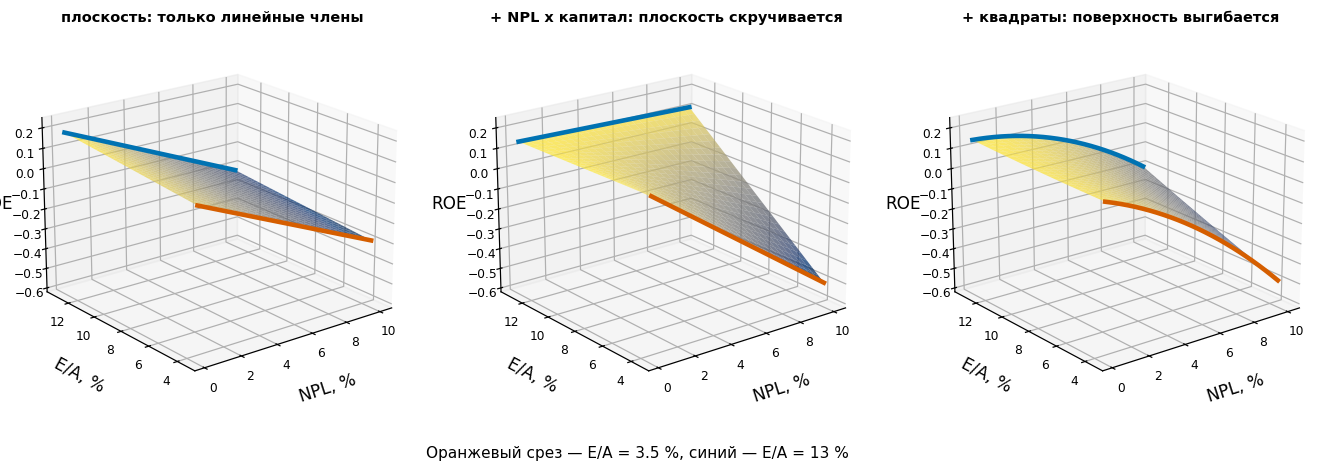

In [29]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(13, 4.4))
for k, (title, Z) in enumerate(surfaces):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(NG * 100, EG * 100, Z, cmap="cividis", alpha=0.72,
                    linewidth=0, antialiased=True, rstride=1, cstride=1)
    for row, col in [(0, "#D55E00"), (-1, "#0072B2")]:
        ax.plot(npl_ax * 100, np.full_like(npl_ax, eq_ax[row] * 100), Z[row],
                color=col, lw=3.0, zorder=10)
    ax.set(xlabel="NPL, %", ylabel="E/A, %", zlim=(-0.62, 0.25))
    ax.set_zlabel("ROE", labelpad=-2)
    ax.set_title(title, fontsize=9.5, pad=0)
    ax.view_init(elev=20, azim=-128)
    ax.tick_params(labelsize=8, pad=-1)
fig.suptitle("Оранжевый срез — E/A = 3.5 %, синий — E/A = 13 %", y=0.06, fontsize=10)
fig.subplots_adjust(left=0.05, right=0.99, top=0.93, bottom=0.13, wspace=0.04)
plt.show()

* **Плоскость.** Оранжевый и синий срезы **параллельны**: наклон −4.05 и там,
  и там. Модель утверждает, что процентный пункт просрочки стоит одинаково
  банку с капиталом 3.5 % и банку с капиталом 13 %. Это утверждение, а не
  нейтральность — и оно почти наверняка ложно.
* **Со взаимодействием.** Плоскость скручивается: срезы расходятся веером,
  наклон **−6.63 против −0.25** — разница в двадцать шесть раз. Поверхность
  всё ещё состоит из прямых (любой её срез — прямая), но из прямых **разного
  наклона**. Отсюда и название «линейчатая».
* **С квадратами.** Теперь гнутся и сами срезы: наклон меняется не только
  между банками с разным капиталом (−6.25 против −3.48), но и по мере роста
  самой просрочки — вдоль каждой отдельной линии.

Ровно это и означает «выйти за пределы линейности»: не «модель стала лучше»,
а **отклик перестал быть одинаковым на разных участках пространства
признаков**. Каждый добавленный член — конкретное содержательное утверждение
о том, где именно он разный. Утверждать это надо осознанно; в §6.5 —
как проверить, что вы не выдумали.

### 6.4 Взаимодействие: наклон, который зависит от другой переменной

Гипотеза сформулирована из тождества, а не подобрана по данным: *эффект NPL на
ROE должен быть сильнее у банков с тонким капиталом*. Проверяем.

In [30]:
inter = smf.ols(base6 + " + a_npl_gross_loans:c_equity_assets", data=roe_df).fit(
    cov_type="cluster", cov_kwds={"groups": roe_df["cert"]})
print(inter.summary().tables[1])

                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.1909      0.006     30.003      0.000       0.178       0.203
c_equity_assets                      -0.2834      0.043     -6.551      0.000      -0.368      -0.199
a_npl_gross_loans                    -8.9736      0.247    -36.339      0.000      -9.458      -8.490
m_cost_income                        -0.0759      0.004    -19.238      0.000      -0.084      -0.068
l_loans_deposits                     -0.0004      0.003     -0.140      0.889      -0.006       0.005
s_securities_assets                   0.0072      0.005      1.430      0.153      -0.003       0.017
a_llr_npl_coverage                    0.0225      0.002     11.476      0.000       0.019       0.026
a_npl_gross_loans:c_equity_assets    67.0932      2.444     27.447      0.000     

Коэффициент при взаимодействии — **67.1**. Что это за число? Оно отвечает на
вопрос «что будет с ROE, если произведение NPL на достаточность капитала
вырастет на единицу» — приращение, недоступное ни одному банку на Земле.
Прочитать его напрямую нельзя.

**Правило: коэффициент при взаимодействии не интерпретируется в одиночку.**
Интерпретируется производная. Если

$$\text{ROE} = \dots + \beta_{\text{npl}}\,\text{NPL} + \beta_{\times}\,\text{NPL}\times\text{Eq},$$

то предельный эффект NPL зависит от капитала:

$$\frac{\partial\,\text{ROE}}{\partial\,\text{NPL}} = \beta_{\text{npl}} + \beta_{\times}\cdot \text{Eq}.$$

Заметьте, что $\beta_{\text{npl}} = -8.97$ из таблицы — это предельный эффект
NPL **при нулевом капитале**. Не «эффект NPL в среднем», а эффект в точке,
которой не бывает. Как только в модели появляется взаимодействие, главные
коэффициенты меняют смысл — и это источник примерно половины ошибок
интерпретации, которые я видел.

Считаем производную при трёх уровнях достаточности капитала: тонком (5 %),
среднем (8 %) и комфортном (11 %). Стандартную ошибку — по дельта-методу,
через ковариацию двух коэффициентов; брать SE только одного из них было бы
неверно.

In [31]:
b_npl = inter.params["a_npl_gross_loans"]
b_x = inter.params["a_npl_gross_loans:c_equity_assets"]
cov = inter.cov_params().loc[["a_npl_gross_loans", "a_npl_gross_loans:c_equity_assets"],
                             ["a_npl_gross_loans", "a_npl_gross_loans:c_equity_assets"]]
rows = []
for eq in (0.05, 0.08, 0.11):
    g = np.array([1.0, eq])                     # d(ROE)/d(NPL) = b_npl + b_x * eq
    me = b_npl + b_x * eq
    se = np.sqrt(g @ cov.to_numpy() @ g)
    rows.append({"equity/assets": eq, "dROE/dNPL": me, "se": se,
                 "ROE, п.п. на +1 п.п. NPL": me * 0.01 * 100})
pd.DataFrame(rows).set_index("equity/assets").round(3)

,dROE/dNPL,se,"ROE, п.п. на +1 п.п. NPL"
equity/assets,,,
0.05,-5.619,0.129,-5.619
0.08,-3.606,0.065,-3.606
0.11,-1.593,0.052,-1.593


Вот это уже высказывание для комитета по рискам:

> Рост доли проблемных кредитов на один процентный пункт стоит банку с
> капиталом 5 % примерно **5.6 п.п. ROE**, банку с капиталом 11 % —
> примерно **1.6 п.п.**, то есть в три с половиной раза меньше.

Это и есть содержание взаимодействия: не «есть эффект», а «эффект зависит
от». Нарисуем то же самое — две линии предсказанного ROE вместо одной.

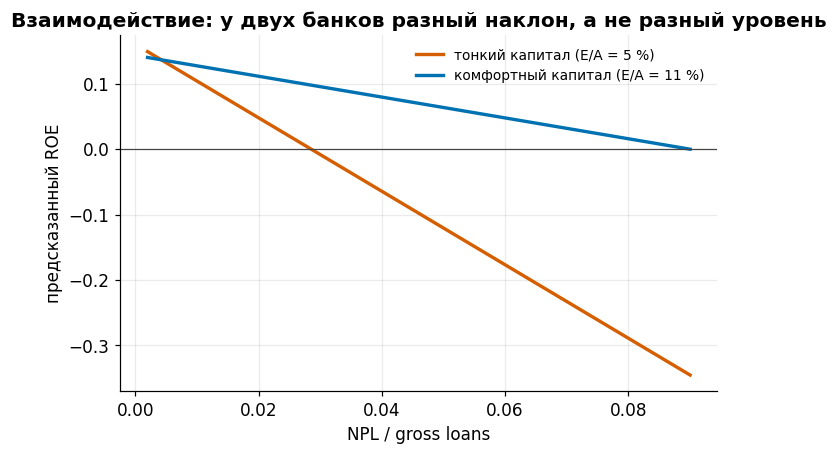

In [32]:
grid = np.linspace(0.002, 0.09, 60)
base_row = roe_df[FEAT6].median().to_dict()
fig, ax = plt.subplots()
for eq, col, lab in [(0.05, "#D55E00", "тонкий капитал (E/A = 5 %)"),
                     (0.11, "#0072B2", "комфортный капитал (E/A = 11 %)")]:
    scen = pd.DataFrame([{**base_row, "a_npl_gross_loans": g,
                          "c_equity_assets": eq} for g in grid])
    ax.plot(grid, inter.predict(scen), color=col, lw=2.2, label=lab)
ax.axhline(0, color="#444444", lw=0.8)
ax.set(xlabel="NPL / gross loans", ylabel="предсказанный ROE",
       title="Взаимодействие: у двух банков разный наклон, а не разный уровень")
ax.legend(fontsize=9)
plt.show()

Без взаимодействия эти две линии были бы **параллельны** — капитал сдвигал бы
уровень, но не наклон. Взаимодействие разрешает им расходиться. Именно это вы
и утверждаете, когда его добавляете, — и именно это надо уметь защитить.

### 6.5 Когда это оправдано: три условия, а не одно

Гибкость почти всегда улучшает подгонку — и почти никогда не улучшает её
*бесплатно*. Мой критерий: добавляйте нелинейный член, только если выполнены
**все три** условия.

1. **Есть причина ждать нелинейности** — тождество, институт, теория. Здесь:
   ROE = ROA × леверидж.
2. **Диагностика её показывает** — биннированное среднее гнётся, остатки
   систематически смещены (§3.1, §6.2).
3. **Отложенная выборка это подтверждает.** Не $R^2$ на обучении — он вырастет
   всегда.

Проверим условие 3 на обеих моделях: там, где нелинейность обоснована (ROE),
и там, где мы просто закидали модель квадратами (ROA).

In [33]:
tr6 = (roe_df.repdte <= "2015-12-31").to_numpy()
te6 = ~tr6
distressed = te6 & (roe_df.a_npl_gross_loans > 0.03).to_numpy()

def oos(spec, frame, tr_m, te_m, target, subset=None):
    m = smf.ols(spec, data=frame[tr_m]).fit()
    row = {"RMSE_test": rmse(frame.loc[te_m, target], m.predict(frame[te_m]))}
    if subset is not None:
        row["RMSE_distressed"] = rmse(frame.loc[subset, target], m.predict(frame[subset]))
    return row

verdict = pd.DataFrame([
    {"spec": "ROE ~ линейно", **oos(base6, roe_df, tr6, te6, "e_roe", distressed)},
    {"spec": "ROE ~ + NPL x капитал",
     **oos(base6 + " + a_npl_gross_loans:c_equity_assets", roe_df, tr6, te6,
           "e_roe", distressed)},
]).set_index("spec")
print(f"строк в тесте: {te6.sum():,} | из них проблемных (NPL > 3 %): {distressed.sum()}")
verdict.round(5)

строк в тесте: 17,584 | из них проблемных (NPL > 3 %): 32


,RMSE_test,RMSE_distressed
spec,,
ROE ~ линейно,0.0457,0.06872
ROE ~ + NPL x капитал,0.04362,0.04434


Взаимодействие снижает ошибку прогноза ROE на **4.5 %** по всей отложенной
выборке — и на **35 %** на подвыборке проблемных банков (0.0687 → 0.0443).
Улучшение сосредоточено ровно там, где теория его и обещала. Это подтверждение,
а не совпадение.

Теперь контрольный опыт: та же процедура, но без пункта 1 — просто добавим
квадрат NPL в модель ROA, потому что «на графике вроде гнулось».

In [34]:
naive_flex = pd.DataFrame([
    {"spec": "ROA ~ линейно",
     **oos("e_roa ~ " + " + ".join(FEATURES), fit_df, train, test, "e_roa")},
    {"spec": "ROA ~ + NPL^2",
     **oos("e_roa ~ " + " + ".join(FEATURES) + " + I(a_npl_gross_loans**2)",
           fit_df, train, test, "e_roa")},
    {"spec": "ROA ~ + NPL^2 + NPL^3",
     **oos("e_roa ~ " + " + ".join(FEATURES) +
           " + I(a_npl_gross_loans**2) + I(a_npl_gross_loans**3)",
           fit_df, train, test, "e_roa")},
]).set_index("spec")
(naive_flex * 1e4).round(2)

,RMSE_test
spec,
ROA ~ линейно,45.36
ROA ~ + NPL^2,45.34
ROA ~ + NPL^2 + NPL^3,45.34


Ошибка не двигается в четвёртом знаке. Кривизна ROA по NPL **реальна** — мы её
видели на графике, — но живёт она в 0.2 % наблюдений, а RMSE усредняет по всем.
Средняя метрика её просто не замечает.

Это не «нелинейность не нужна». Это: **метрика должна соответствовать вопросу.**
Если вас интересуют именно проблемные банки — а в этом курсе интересуют
именно они, — усреднённый RMSE по всей панели вам врёт, и надо смотреть на
подвыборку или менять целевую функцию. С S4 мы это и сделаем.

> **Две ловушки напоследок.** (1) Полиномы степени выше 3 почти всегда ошибка:
> они дико осциллируют на краях — вспомните степень 9 в §5.2. Нужна гибкость —
> берите сплайны. (2) Экстраполяция за пределы данных после добавления
> квадрата — не осторожная, а произвольная: за границей выборки квадратичный
> член доминирует, и модель уверенно предсказывает что угодно.

## 7 · Соседние модели, коротко — Neighbouring models, briefly

Линейная регрессия — частный случай более широкого объекта. **Обобщённая
линейная модель (GLM)** состоит из трёх частей: линейного предиктора
$\eta = X\beta$, **функции связи** $g$ с $g(\mathbb{E}[y]) = \eta$, и
**распределения** отклика. Меняете две последние — получаете нужную модель,
не меняя ни логики, ни чтения коэффициентов.

| Модель | Отклик $y$ | Связь $g$ | $\beta$ читается как | Где в курсе |
|---|---|---|---|---|
| OLS | вещественный | тождество | единицы $y$ | S2 |
| **Логистическая** | 0/1 | логит | **лог-шансы**; $e^\beta$ — отношение шансов | **S4** |
| **Пуассон** | счётчик 0,1,2,… | лог | $e^\beta$ — во сколько раз больше событий | S7 |
| **Бета** | доля в (0,1) | логит | лог-шансы доли | — |
| Гамма | положительный, скошенный | лог | % изменения | LGD в кредитном риске |

А **kNN** — не GLM вовсе: он не оценивает $\beta$, а усредняет $k$ ближайших
соседей. Полезный контраст, потому что показывает цену отказа от формы.

### 7.1 Логистическая: почему для 0/1 нельзя просто OLS

Возьмём цель курса — `failed_next_4q` — и предскажем её по доле NPL двумя
способами: линейной вероятностной моделью (обычный МНК по 0/1) и логитом.

In [35]:
import statsmodels.api as sm
bin_df = panel[["failed_next_4q", "a_npl_gross_loans"]].dropna().copy()
bin_df["y"] = bin_df.failed_next_4q.astype(int)
lpm = smf.ols("y ~ a_npl_gross_loans", data=bin_df).fit()
logit = smf.glm("y ~ a_npl_gross_loans", data=bin_df,
                family=sm.families.Binomial()).fit()
g = pd.DataFrame({"a_npl_gross_loans": np.linspace(0, 0.14, 120)})
print(f"логит: коэффициент {logit.params['a_npl_gross_loans']:.1f} на долю; "
      f"+1 п.п. NPL умножает шансы краха на "
      f"{np.exp(logit.params['a_npl_gross_loans'] * 0.01):.2f}")
print(f"ЛВМ при NPL = 0 предсказывает вероятность "
      f"{lpm.predict(pd.DataFrame({'a_npl_gross_loans': [0.0]})).iloc[0]:.3f}")

логит: коэффициент 209.4 на долю; +1 п.п. NPL умножает шансы краха на 8.12
ЛВМ при NPL = 0 предсказывает вероятность -0.061


Линейная вероятностная модель предсказывает вероятность краха **−6.1 %** для
здорового банка. Это не «неточность» — это бессмыслица, и она видна на графике.

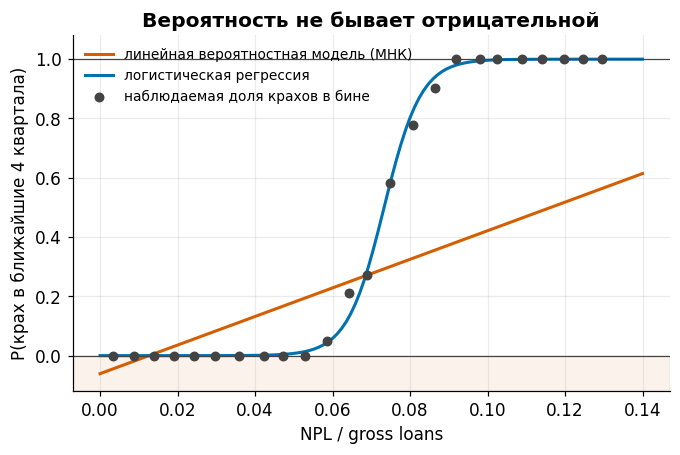

In [36]:
obs = binned_means(bin_df.a_npl_gross_loans, bin_df.y, 24, equal_width=True)
fig, ax = plt.subplots()
ax.plot(g.a_npl_gross_loans, lpm.predict(g), color="#D55E00", lw=2,
        label="линейная вероятностная модель (МНК)")
ax.plot(g.a_npl_gross_loans, logit.predict(g), color="#0072B2", lw=2,
        label="логистическая регрессия")
ax.scatter(obs.x, obs.y, s=30, color="#444444", zorder=3,
           label="наблюдаемая доля крахов в бине")
ax.axhspan(-0.12, 0, color="#D55E00", alpha=0.08)
ax.axhline(0, color="#444444", lw=0.8); ax.axhline(1, color="#444444", lw=0.8)
ax.set(xlabel="NPL / gross loans", ylabel="P(крах в ближайшие 4 квартала)",
       ylim=(-0.12, 1.08), title="Вероятность не бывает отрицательной")
ax.legend(loc="upper left", fontsize=9)
plt.show()

Логит по построению живёт в $(0, 1)$ и воспроизводит S-образную форму, которую
видно в наблюдаемых долях. Ценой становится чтение коэффициентов: они теперь
в лог-шансах, а предельный эффект зависит от точки. Полностью — в S4.

### 7.2 Пуассон: когда отклик — счётчик

Сколько банков падает за квартал? Это неотрицательное целое число, часто ноль.
Нормальное распределение тут не подходит. Пуассоновская регрессия с
логарифмической связью моделирует $\log \mathbb{E}[\text{count}]$, поэтому
$e^\beta$ читается как **множитель интенсивности**.

In [37]:
fails = pd.read_parquet(DATA + "failures.parquet")
q_index = pd.period_range("2001Q1", "2023Q4", freq="Q")
counts = fails.groupby(fails.fail_date.dt.to_period("Q")).size().reindex(q_index, fill_value=0)
cnt_df = pd.DataFrame({"quarter": q_index.to_timestamp(how="end").normalize(),
                       "n": counts.to_numpy()})
cnt_df["crisis"] = ((cnt_df.quarter.dt.year >= 2008) &
                    (cnt_df.quarter.dt.year <= 2012)).astype(int)
pois = smf.glm("n ~ crisis", data=cnt_df, family=sm.families.Poisson()).fit()
print(f"крахов всего: {cnt_df.n.sum()} за {len(cnt_df)} кварталов "
      f"(максимум {cnt_df.n.max()} за квартал)")
print(f"IRR кризиса = exp({pois.params['crisis']:.2f}) = "
      f"{np.exp(pois.params['crisis']):.1f}x интенсивность вне 2008-2012")

крахов всего: 47 за 92 кварталов (максимум 5 за квартал)
IRR кризиса = exp(3.66) = 38.7x интенсивность вне 2008-2012


«В 2008–2012 банки падали в 38.7 раза чаще, чем в остальные годы» — одно число,
сразу читаемое. Это же семейство появится в S7: дискретная модель риска —
близкий родственник Пуассона и логита.

### 7.3 Бета: когда отклик — доля

Многие банковские переменные — доли в $(0,1)$: покрытие резервами, доля
брокерских депозитов, LGD. МНК их допускает выходить за границы, бета-регрессия
нет: она моделирует **логит доли**, а второй параметр (`precision`) отвечает за
разброс вокруг среднего.

In [38]:
from statsmodels.othermod.betareg import BetaModel
share_df = panel[["l_brokered_share", "a_npl_gross_loans"]].replace(
    [np.inf, -np.inf], np.nan).dropna()
share_df = share_df[(share_df.l_brokered_share > 0) & (share_df.l_brokered_share < 1)]
beta_m = BetaModel.from_formula("l_brokered_share ~ a_npl_gross_loans",
                                share_df).fit()
print(beta_m.params.round(3).to_string())
print("\nчитается как логит доли: +1 п.п. NPL умножает шансы «депозит брокерский» на",
      round(float(np.exp(beta_m.params['a_npl_gross_loans'] * 0.01)), 3))

Intercept           -2.935
a_npl_gross_loans    18.14
precision            4.644

читается как логит доли: +1 п.п. NPL умножает шансы «депозит брокерский» на 1.199


Знак содержательный: банки с растущей просрочкой замещают уходящие розничные
депозиты брокерскими — самый дорогой источник фондирования. Это будет одним из
сильных предикторов в S4.

### 7.4 kNN: цена отказа от формы

k ближайших соседей не предполагает вообще ничего о форме $f$: прогноз — это
среднее $y$ у $k$ ближайших по признакам наблюдений. Максимальная гибкость.
Проверим на нашей же задаче (те же 7 признаков, то же разбиение по времени),
чем эта гибкость оплачивается.

In [39]:
from sklearn.neighbors import KNeighborsRegressor
ks = [1, 5, 25, 100, 400]
knn_rows = []
for k in ks:
    pipe = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    pipe.fit(X[train], y[train])
    knn_rows.append({"k": k, "RMSE_bps": rmse(y[test], pipe.predict(X[test])) * 1e4})
knn = pd.DataFrame(knn_rows).set_index("k")
knn.loc["OLS", "RMSE_bps"] = rmse(y[test], p_test) * 1e4
knn.loc["среднее обучения", "RMSE_bps"] = rmse(y[test], naive_mean) * 1e4
knn.round(2)

,RMSE_bps
k,
1,65.1
5,49.92
25,46.32
100,45.74
400,45.72
OLS,45.36
среднее обучения,49.47


kNN **не побеждает нигде**, при любом $k$. При $k=1$ он даже хуже, чем
предсказывать константу.

Причина — «проклятие размерности». В семи измерениях «ближайшие соседи» уже не
близкие: чтобы захватить 10 % выборки в кубе, по каждой оси надо взять
$0.1^{1/7} \approx 0.72$, то есть три четверти диапазона. Соседи оказываются
далеко, усреднение смазывает, гибкость не окупается.

**Общая мораль §7:** линейность — не наивность, а *предпосылка, которая
экономит наблюдения*. Когда она примерно верна, отказ от неё стоит дороже, чем
приносит. А проверять это надо на отложенной выборке — той самой процедурой,
которую вы построите в S3.

## 8 · Итог — Takeaways

1. **Регрессия оценивает условное среднее прямой.** Не «истину», а её линейное
   приближение — лучшее в смысле квадратичной ошибки.
2. **Коэффициент — это FWL-остаток.** «При прочих равных» означает буквально
   «после вычитания проекции на остальные регрессоры».
3. **Предпосылки защищают разные утверждения.** Экзогенность защищает
   интерпретацию и непроверяема; гомоскедастичность и независимость защищают
   только SE; для прогноза не нужно почти ничего.
4. **Коллинеарность губит вывод, а не прогноз.** $R^2$ не шелохнулся, а SE
   выросла в десять раз.
5. **Кластеризуйте по единице процесса.** Здесь — по банку; SE вырастают в 5–6
   раз, и часть «значимых» результатов испаряется.
6. **$R^2$ нельзя сравнивать между выборками**; RMSE — можно. И то и другое —
   только против наивной модели.
7. **Опасность гибкости = число параметров на наблюдение**, а не число
   параметров.
8. **Нелинейность добавляют по трём условиям сразу:** причина + диагностика +
   отложенная выборка. Коэффициент при взаимодействии читают производной, а не
   глазами.
9. **Средняя метрика прячет то, что происходит в хвосте** — а в этом курсе
   интересен именно хвост.
10. **GLM — это OLS со сменённой связью и распределением.** Логит для 0/1,
    Пуассон для счётчиков, бета для долей.

### Что дальше

**S3** возьмёт пункт 7 и превратит его в инструмент: регуляризация — это
осознанная покупка смещения за дисперсию, а правильное разбиение панели —
единственная защита от того, чтобы прогноз оказался обманчиво лёгким.

**HW1** — та же логика на ваших руках: одна таблица вывода, одна оценка
прогноза, и 250 слов о том, почему два критерия выбирают разные спецификации.